In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/open-problems-multimodal/sample_submission.csv
/kaggle/input/competitions/open-problems-multimodal/train_cite_targets.h5
/kaggle/input/competitions/open-problems-multimodal/metadata_cite_day_2_donor_27678.csv
/kaggle/input/competitions/open-problems-multimodal/test_multi_inputs.h5
/kaggle/input/competitions/open-problems-multimodal/evaluation_ids.csv
/kaggle/input/competitions/open-problems-multimodal/train_cite_inputs.h5
/kaggle/input/competitions/open-problems-multimodal/train_multi_targets.h5
/kaggle/input/competitions/open-problems-multimodal/train_multi_inputs.h5
/kaggle/input/competitions/open-problems-multimodal/metadata.csv
/kaggle/input/competitions/open-problems-multimodal/test_cite_inputs_day_2_donor_27678.h5
/kaggle/input/competitions/open-problems-multimodal/test_cite_inputs.h5


In [9]:
from pathlib import Path

DATA_DIR = Path("/kaggle/input/competitions/open-problems-multimodal")

files = sorted(DATA_DIR.iterdir())

for file in files:
    size_gb = file.stat().st_size / 1024**3
    print(f"{file.name:35s} {size_gb:.3f} GB")

evaluation_ids.csv                  2.252 GB
metadata.csv                        0.009 GB
metadata_cite_day_2_donor_27678.csv 0.000 GB
sample_submission.csv               0.786 GB
test_cite_inputs.h5                 1.588 GB
test_cite_inputs_day_2_donor_27678.h5 0.287 GB
test_multi_inputs.h5                6.029 GB
train_cite_inputs.h5                2.327 GB
train_cite_targets.h5               0.036 GB
train_multi_inputs.h5               10.556 GB
train_multi_targets.h5              2.994 GB


In [10]:
import pandas as pd

metadata_path = DATA_DIR / "metadata.csv"
metadata = pd.read_csv(metadata_path)

print("Metadata shape:", metadata.shape)
display(metadata.head())

print("\nData types:")
print(metadata.dtypes)

print("\nTechnology counts:")
print(metadata["technology"].value_counts())

print("\nDay × technology:")
display(pd.crosstab(metadata["day"], metadata["technology"]))

print("\nDonor × technology:")
display(pd.crosstab(metadata["donor"], metadata["technology"]))

print("\nCell-type counts:")
print(metadata["cell_type"].value_counts(dropna=False))

Metadata shape: (281528, 5)


,cell_id,day,donor,cell_type,technology
0,c2150f55becb,2,27678,HSC,citeseq
1,65b7edf8a4da,2,27678,HSC,citeseq
2,c1b26cb1057b,2,27678,EryP,citeseq
3,917168fa6f83,2,27678,NeuP,citeseq
4,2b29feeca86d,2,27678,EryP,citeseq



Data types:
cell_id       object
day            int64
donor          int64
cell_type     object
technology    object
dtype: object

Technology counts:
technology
multiome    161877
citeseq     119651
Name: count, dtype: int64

Day × technology:


technology,citeseq,multiome
day,,
2,29418,32832
3,27389,36765
4,35977,31134
7,26867,29373
10,0,31773



Donor × technology:


technology,citeseq,multiome
donor,,
13176,29394,43817
27678,28043,32952
31800,30974,43989
32606,31240,41119



Cell-type counts:
cell_type
HSC       77535
hidden    55935
NeuP      42979
EryP      41479
MasP      34827
MkP       24021
MoP        3883
BP          869
Name: count, dtype: int64


Testing Over. Codes begin here.

# 1. First Model: CITE RNA -> protein expression

## 1.1 Environment and files

In [11]:
from pathlib import Path
import gc
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupKFold

In [12]:
DATA_DIR = Path(
    "/kaggle/input/competitions/open-problems-multimodal"
)

OUTPUT_DIR = Path("/kaggle/working")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# only CITE data needed
METADATA_PATH = DATA_DIR / "metadata.csv"
CITE_INPUT_PATH = DATA_DIR / "train_cite_inputs.h5"
CITE_TARGET_PATH = DATA_DIR / "train_cite_targets.h5"

required_files = [
    METADATA_PATH,
    CITE_INPUT_PATH,
    CITE_TARGET_PATH,
]

for path in required_files:
    print(f"{path.name:30s} exists = {path.exists()}")

metadata.csv                   exists = True
train_cite_inputs.h5           exists = True
train_cite_targets.h5          exists = True


In [13]:
metadata = pd.read_csv(METADATA_PATH)

# cell_id as index
metadata = metadata.set_index("cell_id")

print("Metadata shape:", metadata.shape)
print("Metadata index unique:", metadata.index.is_unique)

# CITE target: 140 cols
y_cite = pd.read_hdf(CITE_TARGET_PATH)

print("\nCITE target shape:", y_cite.shape)
print("CITE target index unique:", y_cite.index.is_unique)

display(metadata.head())
display(y_cite.iloc[:5, :8])

Metadata shape: (281528, 4)
Metadata index unique: True

CITE target shape: (70988, 140)
CITE target index unique: True


,day,donor,cell_type,technology
cell_id,,,,
c2150f55becb,2,27678,HSC,citeseq
65b7edf8a4da,2,27678,HSC,citeseq
c1b26cb1057b,2,27678,EryP,citeseq
917168fa6f83,2,27678,NeuP,citeseq
2b29feeca86d,2,27678,EryP,citeseq


gene_id,CD86,CD274,CD270,CD155,CD112,CD47,CD48,CD40
cell_id,,,,,,,,
45006fe3e4c8,1.167804,0.622530,0.106959,0.324989,3.331674,6.426002,1.480766,-0.728392
d02759a80ba2,0.818970,0.506009,1.078682,6.848758,3.524885,5.279456,4.930438,2.069372
c016c6b0efa5,-0.356703,-0.422261,-0.824493,1.137495,0.518924,7.221962,-0.375034,1.738071
ba7f733a4f75,-1.201507,0.149115,2.022468,6.021595,7.258670,2.792436,21.708519,-0.137913
fbcf2443ffb2,-0.100404,0.697461,0.625836,-0.298404,1.369898,3.254521,-1.659380,0.643531


| Technology | Train cells | Test cells | Total Number |
|---|---:|---:|---:|
| CITE-seq | 70,988 | 48,663 | 119,651 |
| Multiome | 105,942 | 55,935 | 161,877 |
| Total | 176,930 | 104,598 | 281,528 |

## 1.2 Identify CITE train/test metadata

In [14]:
# 只保留CITE-seq细胞
cite_metadata = metadata[
    metadata["technology"] == "citeseq"
].copy()

# 确保所有target中的细胞都存在于metadata中
missing_ids = y_cite.index.difference(cite_metadata.index)

print("Target cell IDs missing from metadata:", len(missing_ids))
assert len(missing_ids) == 0, "Some target cells are missing from metadata."

# 出现在target中的细胞是训练细胞
cite_metadata["split"] = np.where(
    cite_metadata.index.isin(y_cite.index),
    "train",
    "test"
)

# 按target的顺序排列训练metadata
train_cite_metadata = cite_metadata.loc[y_cite.index].copy()

# 没有target的CITE细胞属于测试集
test_cite_metadata = cite_metadata[
    cite_metadata["split"] == "test"
].copy()

print("Total CITE cells:", len(cite_metadata))
print("Training cells:", len(train_cite_metadata))
print("Test cells:", len(test_cite_metadata))

print("\nTrain/test counts:")
print(cite_metadata["split"].value_counts())

Target cell IDs missing from metadata: 0
Total CITE cells: 119651
Training cells: 70988
Test cells: 48663

Train/test counts:
split
train    70988
test     48663
Name: count, dtype: int64


In [15]:
print("Train/test × day:")
display(
    pd.crosstab(
        cite_metadata["split"],
        cite_metadata["day"]
    )
)

print("Train/test × donor:")
display(
    pd.crosstab(
        cite_metadata["split"],
        cite_metadata["donor"]
    )
)

print("Training donor × day:")
display(
    pd.crosstab(
        train_cite_metadata["donor"],
        train_cite_metadata["day"]
    )
)

print("Test donor × day:")
display(
    pd.crosstab(
        test_cite_metadata["donor"],
        test_cite_metadata["day"]
    )
)

print("Train/test × cell type:")
display(
    pd.crosstab(
        cite_metadata["split"],
        cite_metadata["cell_type"]
    )
)

Train/test × day:


day,2,3,4,7
split,,,,
test,7476,6488,7832,26867
train,21942,20901,28145,0


Train/test × donor:


donor,13176,27678,31800,32606
split,,,,
test,7195,28043,6171,7254
train,22199,0,24803,23986


Training donor × day:


day,2,3,4
donor,,,
13176,6071,7643,8485
31800,8395,6259,10149
32606,7476,6999,9511


Test donor × day:


day,2,3,4,7
donor,,,,
13176,0,0,0,7195
27678,7476,6488,7832,6247
31800,0,0,0,6171
32606,0,0,0,7254


Train/test × cell type:


cell_type,BP,EryP,HSC,MasP,MkP,MoP,NeuP
split,,,,,,,
test,143,10103,12995,9848,5418,1231,8925
train,160,14241,29879,8242,5382,591,12493


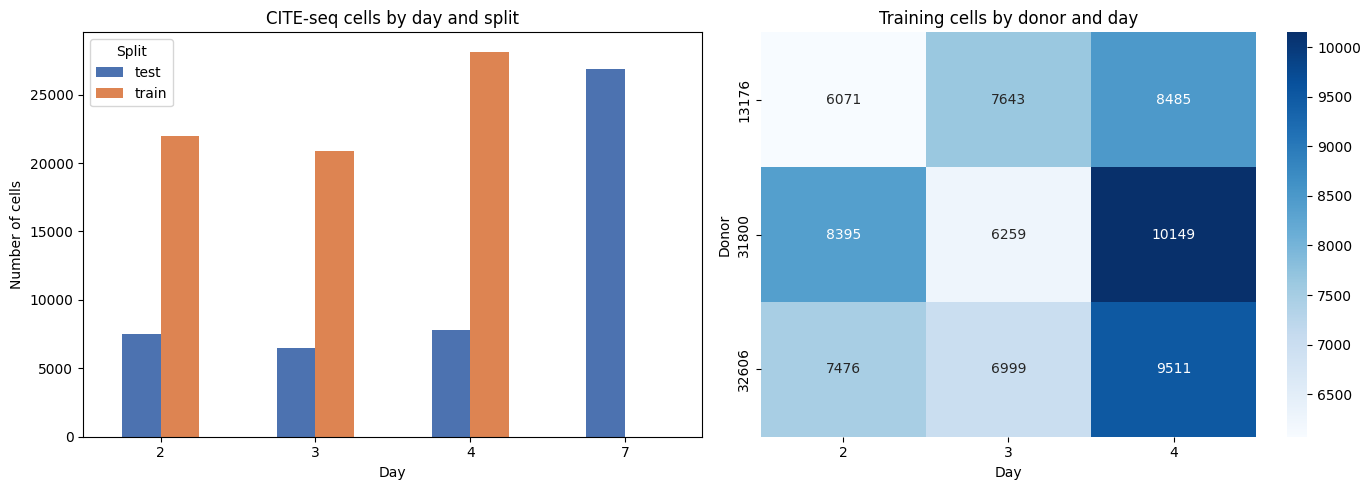

Figure saved to: /kaggle/working/cite_data_distribution.png


In [16]:
# ==============================
# 5. Visualize data distribution
# ==============================

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5)
)

# 左图：train和test在不同day上的细胞数量
day_split_table = pd.crosstab(
    cite_metadata["day"],
    cite_metadata["split"]
)

day_split_table.plot(
    kind="bar",
    ax=axes[0],
    color=["#4C72B0", "#DD8452"]
)

axes[0].set_title("CITE-seq cells by day and split")
axes[0].set_xlabel("Day")
axes[0].set_ylabel("Number of cells")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Split")

# 右图：训练集中每个donor和day的细胞数量
train_donor_day = pd.crosstab(
    train_cite_metadata["donor"],
    train_cite_metadata["day"]
)

sns.heatmap(
    train_donor_day,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[1]
)

axes[1].set_title("Training cells by donor and day")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Donor")

plt.tight_layout()

figure_path = OUTPUT_DIR / "cite_data_distribution.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to:", figure_path)

## 1.3 Read training daata

In [17]:
# ==================================
# 6. Load the CITE-seq input matrix
# ==================================

start_time = time.time()

X_cite = pd.read_hdf(CITE_INPUT_PATH)

elapsed_time = time.time() - start_time

print(f"Loading time: {elapsed_time:.1f} seconds")
print("CITE input shape:", X_cite.shape)
print("Input index unique:", X_cite.index.is_unique)

memory_gb = (
    X_cite.memory_usage(index=True, deep=True).sum()
    / 1024**3
)

print(f"Approximate memory usage: {memory_gb:.2f} GB")
print("\nInput data types:")
print(X_cite.dtypes.value_counts())

Loading time: 49.1 seconds
CITE input shape: (70988, 22050)
Input index unique: True
Approximate memory usage: 5.84 GB

Input data types:
float32    22050
Name: count, dtype: int64


Checking

In [18]:
# ==================================
# 7. Align X, Y and cell metadata
# ==================================

# 检查X和Y包含的cell ID是否完全一致
x_not_in_y = X_cite.index.difference(y_cite.index)
y_not_in_x = y_cite.index.difference(X_cite.index)

print("X cells missing from Y:", len(x_not_in_y))
print("Y cells missing from X:", len(y_not_in_x))

assert len(x_not_in_y) == 0
assert len(y_not_in_x) == 0

# 按X的顺序重新排列Y和metadata
y_cite = y_cite.loc[X_cite.index]
train_cite_metadata = metadata.loc[X_cite.index].copy()

# 再次进行严格检查
assert X_cite.index.equals(y_cite.index)
assert X_cite.index.equals(train_cite_metadata.index)

print("\nAlignment successful.")
print("X shape:", X_cite.shape)
print("Y shape:", y_cite.shape)
print("Metadata shape:", train_cite_metadata.shape)

display(
    train_cite_metadata.head()
)

X cells missing from Y: 0
Y cells missing from X: 0

Alignment successful.
X shape: (70988, 22050)
Y shape: (70988, 140)
Metadata shape: (70988, 4)


,day,donor,cell_type,technology
cell_id,,,,
45006fe3e4c8,2,32606,HSC,citeseq
d02759a80ba2,2,32606,HSC,citeseq
c016c6b0efa5,2,32606,EryP,citeseq
ba7f733a4f75,2,32606,NeuP,citeseq
fbcf2443ffb2,2,32606,EryP,citeseq


In [19]:
# =====================================
# 8. Estimate sparsity using a subsample
# =====================================

rng = np.random.default_rng(42)

sample_size = min(2000, len(X_cite))

sample_positions = rng.choice(
    len(X_cite),
    size=sample_size,
    replace=False
)

# 抽取2000个细胞
X_sample = X_cite.iloc[sample_positions].to_numpy()

zero_fraction = np.mean(X_sample == 0)

detected_genes_per_cell = np.count_nonzero(
    X_sample,
    axis=1
)

print(f"Sampled cells: {sample_size}")
print(f"Estimated zero fraction: {zero_fraction:.2%}")
print(
    "Average detected genes per cell:",
    f"{detected_genes_per_cell.mean():.1f}"
)
print(
    "Median detected genes per cell:",
    f"{np.median(detected_genes_per_cell):.1f}"
)

print("\nSample value statistics:")
print("Minimum:", X_sample.min())
print("Maximum:", X_sample.max())
print("Mean:", X_sample.mean())
print("Standard deviation:", X_sample.std())

# 删除临时数组，释放内存
del X_sample
gc.collect()

Sampled cells: 2000
Estimated zero fraction: 78.05%
Average detected genes per cell: 4840.8
Median detected genes per cell: 4864.0

Sample value statistics:
Minimum: 0.0
Maximum: 11.350636
Mean: 0.9752608
Standard deviation: 1.8957082


0

2 schemes:              
- run for 3 folds, in each round, pick one doner as testing while the rest 2 doners' cells are training;
- use day 4 cells as testing, while day < 4 as training

In [20]:
# ===============================
# 9. Construct validation schemes
# ===============================

# ---------- A. Donor-based validation ----------

unique_donors = train_cite_metadata["donor"].unique()

print("Training donors:", unique_donors)

donor_cv = GroupKFold(
    n_splits=len(unique_donors)
)

donor_fold = np.full(
    len(train_cite_metadata),
    fill_value=-1,
    dtype=np.int8
)

dummy_X = np.zeros(
    (len(train_cite_metadata), 1),
    dtype=np.float32
)

for fold, (train_idx, valid_idx) in enumerate(
    donor_cv.split(
        dummy_X,
        groups=train_cite_metadata["donor"]
    )
):
    donor_fold[valid_idx] = fold

train_cite_metadata["donor_fold"] = donor_fold

print("\nDonor-based folds:")
display(
    pd.crosstab(
        train_cite_metadata["donor_fold"],
        train_cite_metadata["donor"]
    )
)


# ---------- B. Time-based validation ----------

latest_training_day = train_cite_metadata["day"].max()

time_train_mask = (
    train_cite_metadata["day"] < latest_training_day
).to_numpy()

time_valid_mask = (
    train_cite_metadata["day"] == latest_training_day
).to_numpy()

print("Latest training day:", latest_training_day)
print("Temporal training cells:", time_train_mask.sum())
print("Temporal validation cells:", time_valid_mask.sum())

print("\nTemporal training days:")
print(
    train_cite_metadata.loc[
        time_train_mask, "day"
    ].value_counts().sort_index()
)

print("\nTemporal validation days:")
print(
    train_cite_metadata.loc[
        time_valid_mask, "day"
    ].value_counts().sort_index()
)

Training donors: [32606 13176 31800]

Donor-based folds:


donor,13176,31800,32606
donor_fold,,,
0,0,24803,0
1,0,0,23986
2,22199,0,0


Latest training day: 4
Temporal training cells: 42843
Temporal validation cells: 28145

Temporal training days:
day
2    21942
3    20901
Name: count, dtype: int64

Temporal validation days:
day
4    28145
Name: count, dtype: int64


## 1.4 Define evaluation function

In [21]:
import numpy as np
import pandas as pd
import gc
import time

def rowwise_pearson_score(y_true, y_pred, eps=1e-8):
    """
    Calculate Pearson correlation across proteins for each cell,
    then average across all cells.
    """

    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)

    # 对每个细胞的140个蛋白值分别中心化
    y_true_centered = (
        y_true - y_true.mean(axis=1, keepdims=True)
    )
    y_pred_centered = (
        y_pred - y_pred.mean(axis=1, keepdims=True)
    )

    numerator = np.sum(
        y_true_centered * y_pred_centered,
        axis=1
    )

    denominator = np.sqrt(
        np.sum(y_true_centered ** 2, axis=1)
        *
        np.sum(y_pred_centered ** 2, axis=1)
    )

    cell_scores = numerator / np.maximum(
        denominator,
        eps
    )

    return float(np.mean(cell_scores))


# 简单测试：一个矩阵与自身的相关性应当接近1
test_score = rowwise_pearson_score(
    y_cite.iloc[:100].to_numpy(),
    y_cite.iloc[:100].to_numpy()
)

print("Metric self-test:", test_score)
assert np.isclose(test_score, 1.0, atol=1e-5)

Metric self-test: 1.0


## 1.5 Doner 31800 as the testing data

In [22]:
VALID_DONOR = 31800

donor_values = (
    train_cite_metadata["donor"]
    .to_numpy()
)

train_mask = donor_values != VALID_DONOR
valid_mask = donor_values == VALID_DONOR

train_idx = np.flatnonzero(train_mask)
valid_idx = np.flatnonzero(valid_mask)

print("Validation donor:", VALID_DONOR)
print("Training cells:", len(train_idx))
print("Validation cells:", len(valid_idx))

print("\nTraining donors:")
print(
    train_cite_metadata.iloc[train_idx]["donor"]
    .value_counts()
)

print("\nValidation donors:")
print(
    train_cite_metadata.iloc[valid_idx]["donor"]
    .value_counts()
)

print("\nTraining days:")
print(
    train_cite_metadata.iloc[train_idx]["day"]
    .value_counts()
    .sort_index()
)

print("\nValidation days:")
print(
    train_cite_metadata.iloc[valid_idx]["day"]
    .value_counts()
    .sort_index()
)

Validation donor: 31800
Training cells: 46185
Validation cells: 24803

Training donors:
donor
32606    23986
13176    22199
Name: count, dtype: int64

Validation donors:
donor
31800    24803
Name: count, dtype: int64

Training days:
day
2    13547
3    14642
4    17996
Name: count, dtype: int64

Validation days:
day
2     8395
3     6259
4    10149
Name: count, dtype: int64


In [23]:
# ==============================
# 12. Mean-protein baseline
# ==============================

Y = y_cite.to_numpy(
    dtype=np.float32,
    copy=False
)

mean_protein_profile = Y[train_idx].mean(
    axis=0,
    keepdims=True
)

mean_predictions = np.repeat(
    mean_protein_profile,
    repeats=len(valid_idx),
    axis=0
)

mean_baseline_score = rowwise_pearson_score(
    Y[valid_idx],
    mean_predictions
)

print(
    "Mean baseline score:",
    f"{mean_baseline_score:.6f}"
)

del mean_predictions
gc.collect()

Mean baseline score: 0.795967


0

In [24]:
# ======================================
# 13. Fit Truncated SVD on training RNA
# ======================================

from sklearn.decomposition import TruncatedSVD

N_COMPONENTS = 128
RANDOM_STATE = 42

# 获取底层float32矩阵，尽量避免复制整个DataFrame
X = X_cite.to_numpy(
    dtype=np.float32,
    copy=False
)

svd = TruncatedSVD(
    n_components=N_COMPONENTS,
    algorithm="randomized",
    n_iter=5,
    random_state=RANDOM_STATE
)

start_time = time.time()

# 只使用两个训练donor拟合SVD
# 这里会临时复制训练子集，可能占用约4 GB额外内存
X_train_fold = X[train_idx]

Z_train = svd.fit_transform(
    X_train_fold
).astype(np.float32)

del X_train_fold
gc.collect()

elapsed_time = time.time() - start_time

print(
    f"SVD fitting time: {elapsed_time / 60:.2f} minutes"
)
print("Training embedding shape:", Z_train.shape)
print(
    "Explained variance ratio:",
    f"{svd.explained_variance_ratio_.sum():.4f}"
)

SVD fitting time: 1.13 minutes
Training embedding shape: (46185, 128)
Explained variance ratio: 0.1382


In [25]:
# =====================================
# 14. Transform validation RNA in batches
# =====================================

def svd_transform_in_batches(
    model,
    X_matrix,
    row_indices,
    batch_size=4000
):
    result = np.empty(
        (len(row_indices), model.n_components),
        dtype=np.float32
    )

    for start in range(
        0,
        len(row_indices),
        batch_size
    ):
        end = min(
            start + batch_size,
            len(row_indices)
        )

        batch_indices = row_indices[start:end]

        result[start:end] = model.transform(
            X_matrix[batch_indices]
        ).astype(np.float32)

        print(
            f"Transformed {end:6d} / "
            f"{len(row_indices):6d} cells"
        )

    return result


start_time = time.time()

Z_valid = svd_transform_in_batches(
    model=svd,
    X_matrix=X,
    row_indices=valid_idx,
    batch_size=4000
)

elapsed_time = time.time() - start_time

print(
    f"\nValidation transformation time: "
    f"{elapsed_time / 60:.2f} minutes"
)
print("Validation embedding shape:", Z_valid.shape)

Transformed   4000 /  24803 cells
Transformed   8000 /  24803 cells
Transformed  12000 /  24803 cells
Transformed  16000 /  24803 cells
Transformed  20000 /  24803 cells
Transformed  24000 /  24803 cells
Transformed  24803 /  24803 cells

Validation transformation time: 0.10 minutes
Validation embedding shape: (24803, 128)


In [26]:
# =====================================
# 15. Train Ridge regression and score
# =====================================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

RIDGE_ALPHA = 10.0

# 标准化128个SVD特征
scaler = StandardScaler()

Z_train_scaled = scaler.fit_transform(
    Z_train
).astype(np.float32)

Z_valid_scaled = scaler.transform(
    Z_valid
).astype(np.float32)

# 一个Ridge模型同时预测140种蛋白
ridge = Ridge(
    alpha=RIDGE_ALPHA,
    fit_intercept=True
)

start_time = time.time()

ridge.fit(
    Z_train_scaled,
    Y[train_idx]
)

valid_predictions = ridge.predict(
    Z_valid_scaled
).astype(np.float32)

elapsed_time = time.time() - start_time

svd_ridge_score = rowwise_pearson_score(
    Y[valid_idx],
    valid_predictions
)

print(
    f"Ridge fitting and prediction time: "
    f"{elapsed_time:.1f} seconds"
)

print("\nValidation results:")
print(
    f"Mean baseline: {mean_baseline_score:.6f}"
)
print(
    f"SVD + Ridge:  {svd_ridge_score:.6f}"
)
print(
    f"Improvement:   "
    f"{svd_ridge_score - mean_baseline_score:+.6f}"
)

Ridge fitting and prediction time: 0.2 seconds

Validation results:
Mean baseline: 0.795967
SVD + Ridge:  0.878686
Improvement:   +0.082720


In [27]:
# ============================
# 16. Save validation results
# ============================

validation_results = pd.DataFrame({
    "model": [
        "Mean baseline",
        "SVD128 + Ridge"
    ],
    "validation": [
        f"Leave donor {VALID_DONOR} out",
        f"Leave donor {VALID_DONOR} out"
    ],
    "score": [
        mean_baseline_score,
        svd_ridge_score
    ],
    "n_train": [
        len(train_idx),
        len(train_idx)
    ],
    "n_valid": [
        len(valid_idx),
        len(valid_idx)
    ]
})

display(validation_results)

result_path = (
    OUTPUT_DIR /
    "cite_first_donor_validation.csv"
)

validation_results.to_csv(
    result_path,
    index=False
)

print("Saved to:", result_path)

,model,validation,score,n_train,n_valid
0,Mean baseline,Leave donor 31800 out,0.795967,46185,24803
1,SVD128 + Ridge,Leave donor 31800 out,0.878686,46185,24803


Saved to: /kaggle/working/cite_first_donor_validation.csv


## 1.6 Rest 2 doners as testing data 

Reusable function block

In [28]:
# ===========================================
# Reusable SVD + Ridge validation function
# ===========================================

import gc
import time
import numpy as np
import pandas as pd

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge


# 确保底层矩阵已经定义
X = X_cite.to_numpy(
    dtype=np.float32,
    copy=False
)

Y = y_cite.to_numpy(
    dtype=np.float32,
    copy=False
)


def transform_in_batches(
    model,
    X_matrix,
    row_indices,
    batch_size=4000
):
    """分批将RNA矩阵转换成SVD特征。"""

    result = np.empty(
        (len(row_indices), model.n_components),
        dtype=np.float32
    )

    for start in range(
        0,
        len(row_indices),
        batch_size
    ):
        end = min(
            start + batch_size,
            len(row_indices)
        )

        result[start:end] = model.transform(
            X_matrix[row_indices[start:end]]
        ).astype(np.float32)

    return result


def evaluate_svd_ridge(
    split_name,
    train_idx,
    valid_idx,
    n_components=128,
    ridge_alpha=10.0,
    batch_size=4000,
    random_state=42
):
    """
    在一个指定的train/validation split上：
    1. 计算均值基线
    2. 重新训练SVD
    3. 重新训练StandardScaler
    4. 重新训练Ridge
    5. 返回两种模型的分数
    """

    print("=" * 60)
    print("Validation:", split_name)
    print("Training cells:", len(train_idx))
    print("Validation cells:", len(valid_idx))

    # ---------- Mean baseline ----------

    mean_profile = Y[train_idx].mean(
        axis=0,
        keepdims=True
    )

    mean_predictions = np.broadcast_to(
        mean_profile,
        (len(valid_idx), Y.shape[1])
    )

    mean_score = rowwise_pearson_score(
        Y[valid_idx],
        mean_predictions
    )

    print(f"Mean baseline score: {mean_score:.6f}")

    # ---------- SVD ----------

    svd = TruncatedSVD(
        n_components=n_components,
        algorithm="randomized",
        n_iter=5,
        random_state=random_state
    )

    start_time = time.time()

    # 只使用当前split的训练细胞拟合SVD
    X_train_fold = X[train_idx]

    Z_train = svd.fit_transform(
        X_train_fold
    ).astype(np.float32)

    del X_train_fold
    gc.collect()

    print(
        "SVD explained variance:",
        f"{svd.explained_variance_ratio_.sum():.4f}"
    )

    # ---------- Transform validation ----------

    Z_valid = transform_in_batches(
        model=svd,
        X_matrix=X,
        row_indices=valid_idx,
        batch_size=batch_size
    )

    # ---------- Standardization ----------

    scaler = StandardScaler()

    Z_train = scaler.fit_transform(
        Z_train
    ).astype(np.float32)

    Z_valid = scaler.transform(
        Z_valid
    ).astype(np.float32)

    # ---------- Ridge ----------

    ridge = Ridge(
        alpha=ridge_alpha,
        fit_intercept=True
    )

    ridge.fit(
        Z_train,
        Y[train_idx]
    )

    predictions = ridge.predict(
        Z_valid
    ).astype(np.float32)

    model_score = rowwise_pearson_score(
        Y[valid_idx],
        predictions
    )

    elapsed_minutes = (
        time.time() - start_time
    ) / 60

    print(f"SVD + Ridge score: {model_score:.6f}")
    print(
        "Improvement over baseline:",
        f"{model_score - mean_score:+.6f}"
    )
    print(
        f"Total running time: "
        f"{elapsed_minutes:.2f} minutes"
    )

    result = pd.DataFrame({
        "model": [
            "Mean baseline",
            f"SVD{n_components} + Ridge"
        ],
        "validation": [
            split_name,
            split_name
        ],
        "score": [
            mean_score,
            model_score
        ],
        "n_train": [
            len(train_idx),
            len(train_idx)
        ],
        "n_valid": [
            len(valid_idx),
            len(valid_idx)
        ]
    })

    # 释放当前fold的中间变量
    del (
        mean_predictions,
        Z_train,
        Z_valid,
        predictions,
        svd,
        scaler,
        ridge
    )

    gc.collect()

    return result

Other 2 doners

In [29]:
# ==================================
# Validate the other two donors
# ==================================

donor_values = (
    train_cite_metadata["donor"]
    .to_numpy()
)

additional_donor_results = []

for valid_donor in [32606, 13176]:

    fold_train_idx = np.flatnonzero(
        donor_values != valid_donor
    )

    fold_valid_idx = np.flatnonzero(
        donor_values == valid_donor
    )

    fold_result = evaluate_svd_ridge(
        split_name=f"Leave donor {valid_donor} out",
        train_idx=fold_train_idx,
        valid_idx=fold_valid_idx,
        n_components=128,
        ridge_alpha=10.0
    )

    additional_donor_results.append(
        fold_result
    )

additional_donor_results = pd.concat(
    additional_donor_results,
    ignore_index=True
)

display(additional_donor_results)

Validation: Leave donor 32606 out
Training cells: 47002
Validation cells: 23986
Mean baseline score: 0.797293
SVD explained variance: 0.1388
SVD + Ridge score: 0.884473
Improvement over baseline: +0.087180
Total running time: 1.19 minutes
Validation: Leave donor 13176 out
Training cells: 48789
Validation cells: 22199
Mean baseline score: 0.811249
SVD explained variance: 0.1340
SVD + Ridge score: 0.881325
Improvement over baseline: +0.070076
Total running time: 1.27 minutes


,model,validation,score,n_train,n_valid
0,Mean baseline,Leave donor 32606 out,0.797293,47002,23986
1,SVD128 + Ridge,Leave donor 32606 out,0.884473,47002,23986
2,Mean baseline,Leave donor 13176 out,0.811249,48789,22199
3,SVD128 + Ridge,Leave donor 13176 out,0.881325,48789,22199


## 1.7 Day 4 as testing

In [30]:
# ==================================
# Day 2 and 3 -> Day 4 validation
# ==================================

day_values = (
    train_cite_metadata["day"]
    .to_numpy()
)

time_train_idx = np.flatnonzero(
    day_values < 4
)

time_valid_idx = np.flatnonzero(
    day_values == 4
)

time_result = evaluate_svd_ridge(
    split_name="Day 2-3 train, Day 4 validation",
    train_idx=time_train_idx,
    valid_idx=time_valid_idx,
    n_components=128,
    ridge_alpha=10.0
)

display(time_result)

Validation: Day 2-3 train, Day 4 validation
Training cells: 42843
Validation cells: 28145
Mean baseline score: 0.777621
SVD explained variance: 0.1395
SVD + Ridge score: 0.876094
Improvement over baseline: +0.098472
Total running time: 1.16 minutes


,model,validation,score,n_train,n_valid
0,Mean baseline,"Day 2-3 train, Day 4 validation",0.777621,42843,28145
1,SVD128 + Ridge,"Day 2-3 train, Day 4 validation",0.876094,42843,28145


In [31]:
# 读取已经完成的donor 31800结果
first_result_path = (
    OUTPUT_DIR /
    "cite_first_donor_validation.csv"
)

first_donor_result = pd.read_csv(
    first_result_path
)

all_validation_results = pd.concat(
    [
        first_donor_result,
        additional_donor_results,
        time_result
    ],
    ignore_index=True
)

display(all_validation_results)

combined_path = (
    OUTPUT_DIR /
    "cite_svd128_ridge_all_validations.csv"
)

all_validation_results.to_csv(
    combined_path,
    index=False
)

print("Saved to:", combined_path)

,model,validation,score,n_train,n_valid
0,Mean baseline,Leave donor 31800 out,0.795967,46185,24803
1,SVD128 + Ridge,Leave donor 31800 out,0.878686,46185,24803
2,Mean baseline,Leave donor 32606 out,0.797293,47002,23986
3,SVD128 + Ridge,Leave donor 32606 out,0.884473,47002,23986
4,Mean baseline,Leave donor 13176 out,0.811249,48789,22199
5,SVD128 + Ridge,Leave donor 13176 out,0.881325,48789,22199
6,Mean baseline,"Day 2-3 train, Day 4 validation",0.777621,42843,28145
7,SVD128 + Ridge,"Day 2-3 train, Day 4 validation",0.876094,42843,28145


Saved to: /kaggle/working/cite_svd128_ridge_all_validations.csv


In [32]:
donor_model_results = all_validation_results[
    (all_validation_results["model"] == "SVD128 + Ridge")
    &
    (all_validation_results["validation"].str.contains(
        "Leave donor"
    ))
]

print(
    "Donor validation mean:",
    donor_model_results["score"].mean()
)

print(
    "Donor validation standard deviation:",
    donor_model_results["score"].std()
)

Donor validation mean: 0.8814948598543803
Donor validation standard deviation: 0.002897052387347221


In [33]:
print("time_valid_idx:", len(time_valid_idx))
print("Day 4 cells:", (day_values == 4).sum())
print(time_result[["validation", "n_valid"]])

time_valid_idx: 28145
Day 4 cells: 28145
                        validation  n_valid
0  Day 2-3 train, Day 4 validation    28145
1  Day 2-3 train, Day 4 validation    28145


## Prioritizing Model paratemers

## 2.1 SNV: 64, 128, 256

In [34]:
# ============================================
# 1. Prepare data and hyperparameter settings
# ============================================

from pathlib import Path
import gc
import time

import numpy as np
import pandas as pd

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge


OUTPUT_DIR = Path("/kaggle/working")
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# 获取底层float32矩阵
X = X_cite.to_numpy(
    dtype=np.float32,
    copy=False
)

Y = y_cite.to_numpy(
    dtype=np.float32,
    copy=False
)


# 要比较的SVD维度
LATENT_DIMS = [64, 128, 256]

# 要比较的Ridge正则化强度
RIDGE_ALPHAS = [
    0.1,
    1.0,
    10.0,
    100.0,
    1000.0,
    10000.0
]

MAX_COMPONENTS = max(LATENT_DIMS)
RANDOM_STATE = 42
BATCH_SIZE = 4000


print("RNA matrix:", X.shape, X.dtype)
print("Protein matrix:", Y.shape, Y.dtype)
print("Latent dimensions:", LATENT_DIMS)
print("Ridge alphas:", RIDGE_ALPHAS)

RNA matrix: (70988, 22050) float32
Protein matrix: (70988, 140) float32
Latent dimensions: [64, 128, 256]
Ridge alphas: [0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0]


In [35]:
# ============================================
# 2. Metric and batched SVD transformation
# ============================================

def rowwise_pearson_score(
    y_true,
    y_pred,
    eps=1e-8
):
    """
    对每个细胞，在140个蛋白之间计算Pearson correlation，
    然后对所有细胞取平均。
    """

    y_true = np.asarray(
        y_true,
        dtype=np.float32
    )

    y_pred = np.asarray(
        y_pred,
        dtype=np.float32
    )

    true_centered = (
        y_true
        - y_true.mean(axis=1, keepdims=True)
    )

    pred_centered = (
        y_pred
        - y_pred.mean(axis=1, keepdims=True)
    )

    numerator = np.sum(
        true_centered * pred_centered,
        axis=1
    )

    denominator = np.sqrt(
        np.sum(true_centered ** 2, axis=1)
        *
        np.sum(pred_centered ** 2, axis=1)
    )

    correlations = numerator / np.maximum(
        denominator,
        eps
    )

    return float(correlations.mean())


def transform_svd_in_batches(
    svd_model,
    X_matrix,
    row_indices,
    batch_size=4000
):
    """
    分批将验证RNA转换成SVD特征，
    避免一次复制整个验证矩阵。
    """

    transformed = np.empty(
        (
            len(row_indices),
            svd_model.n_components
        ),
        dtype=np.float32
    )

    for start in range(
        0,
        len(row_indices),
        batch_size
    ):
        end = min(
            start + batch_size,
            len(row_indices)
        )

        batch_indices = row_indices[start:end]

        transformed[start:end] = (
            svd_model.transform(
                X_matrix[batch_indices]
            )
            .astype(np.float32)
        )

        print(
            f"Transformed "
            f"{end:6d}/{len(row_indices):6d}"
        )

    return transformed

In [36]:
# ============================================
# 3. SVD + Ridge tuning function
# ============================================

def tune_svd_ridge_split(
    split_name,
    train_idx,
    valid_idx,
    output_prefix,
    latent_dims=LATENT_DIMS,
    ridge_alphas=RIDGE_ALPHAS,
    max_components=MAX_COMPONENTS,
    batch_size=BATCH_SIZE,
    random_state=RANDOM_STATE
):
    """
    在一个验证方案中：

    1. 计算mean baseline
    2. 拟合一次最大维度SVD
    3. 分别取前64/128/256维
    4. 测试多个Ridge alpha
    5. 保存结果和SVD embedding
    """

    print("=" * 70)
    print("Validation:", split_name)
    print("Training cells:", len(train_idx))
    print("Validation cells:", len(valid_idx))
    print("=" * 70)

    total_start = time.time()

    # --------------------------------
    # A. Mean baseline
    # --------------------------------

    mean_profile = Y[train_idx].mean(
        axis=0,
        keepdims=True
    )

    mean_predictions = np.broadcast_to(
        mean_profile,
        (len(valid_idx), Y.shape[1])
    )

    mean_score = rowwise_pearson_score(
        Y[valid_idx],
        mean_predictions
    )

    print(
        f"\nMean baseline score: "
        f"{mean_score:.6f}"
    )

    # --------------------------------
    # B. Fit one 256-dimensional SVD
    # --------------------------------

    svd = TruncatedSVD(
        n_components=max_components,
        algorithm="randomized",
        n_iter=5,
        random_state=random_state
    )

    svd_start = time.time()

    # 临时创建当前训练子集
    X_train_fold = X[train_idx]

    Z_train = svd.fit_transform(
        X_train_fold
    ).astype(np.float32)

    del X_train_fold
    gc.collect()

    print(
        f"\nSVD fitting time: "
        f"{(time.time() - svd_start) / 60:.2f} minutes"
    )

    print(
        "Maximum embedding shape:",
        Z_train.shape
    )

    # --------------------------------
    # C. Transform validation set
    # --------------------------------

    Z_valid = transform_svd_in_batches(
        svd_model=svd,
        X_matrix=X,
        row_indices=valid_idx,
        batch_size=batch_size
    )

    print(
        "Validation embedding shape:",
        Z_valid.shape
    )

    # --------------------------------
    # D. Standardize SVD components
    # --------------------------------

    scaler = StandardScaler()

    Z_train = scaler.fit_transform(
        Z_train
    ).astype(np.float32)

    Z_valid = scaler.transform(
        Z_valid
    ).astype(np.float32)

    # 保存embedding，以后测试metadata或其他alpha时
    # 不需要重新运行SVD
    embedding_path = (
        OUTPUT_DIR /
        f"{output_prefix}_svd256_embeddings.npz"
    )

    np.savez_compressed(
        embedding_path,
        Z_train=Z_train,
        Z_valid=Z_valid,
        train_idx=train_idx,
        valid_idx=valid_idx
    )

    print(
        "\nEmbeddings saved to:",
        embedding_path
    )

    # --------------------------------
    # E. Ridge parameter search
    # --------------------------------

    explained_variance_cumulative = np.cumsum(
        svd.explained_variance_ratio_
    )

    records = []

    # 先保存mean baseline
    records.append({
        "model": "Mean baseline",
        "validation": split_name,
        "latent_dim": 0,
        "ridge_alpha": np.nan,
        "score": mean_score,
        "explained_variance": np.nan,
        "n_train": len(train_idx),
        "n_valid": len(valid_idx)
    })

    print("\nRidge grid search:")

    for latent_dim in latent_dims:

        # 只取前latent_dim个SVD分量
        Z_train_current = Z_train[
            :, :latent_dim
        ]

        Z_valid_current = Z_valid[
            :, :latent_dim
        ]

        explained_variance = (
            explained_variance_cumulative[
                latent_dim - 1
            ]
        )

        for alpha in ridge_alphas:

            ridge_start = time.time()

            ridge = Ridge(
                alpha=alpha,
                fit_intercept=True
            )

            ridge.fit(
                Z_train_current,
                Y[train_idx]
            )

            predictions = ridge.predict(
                Z_valid_current
            ).astype(np.float32)

            score = rowwise_pearson_score(
                Y[valid_idx],
                predictions
            )

            ridge_seconds = (
                time.time() - ridge_start
            )

            print(
                f"dim={latent_dim:3d}, "
                f"alpha={alpha:8.1f}, "
                f"score={score:.6f}, "
                f"time={ridge_seconds:.1f}s"
            )

            records.append({
                "model": "SVD + Ridge",
                "validation": split_name,
                "latent_dim": latent_dim,
                "ridge_alpha": alpha,
                "score": score,
                "explained_variance": explained_variance,
                "n_train": len(train_idx),
                "n_valid": len(valid_idx)
            })

            del predictions, ridge

    results = pd.DataFrame(records)

    # 保存当前验证方案全部结果
    result_path = (
        OUTPUT_DIR /
        f"{output_prefix}_ridge_grid.csv"
    )

    results.to_csv(
        result_path,
        index=False
    )

    print(
        f"\nTotal time: "
        f"{(time.time() - total_start) / 60:.2f} minutes"
    )

    print("Results saved to:", result_path)

    # 释放大变量
    del (
        Z_train,
        Z_valid,
        svd,
        scaler,
        mean_predictions
    )

    gc.collect()

    return results

SNV calculation on 1 doner

In [37]:
# ============================================
# 4. Screen parameters on unseen-donor split
# ============================================

donor_values = (
    train_cite_metadata["donor"]
    .to_numpy()
)

SCREEN_DONOR = 31800

donor_train_idx = np.flatnonzero(
    donor_values != SCREEN_DONOR
)

donor_valid_idx = np.flatnonzero(
    donor_values == SCREEN_DONOR
)

print("Screening donor:", SCREEN_DONOR)
print("Training cells:", len(donor_train_idx))
print("Validation cells:", len(donor_valid_idx))

donor_grid_results = tune_svd_ridge_split(
    split_name="Leave donor 31800 out",
    train_idx=donor_train_idx,
    valid_idx=donor_valid_idx,
    output_prefix="cite_tuning_donor31800"
)

display(
    donor_grid_results.sort_values(
        "score",
        ascending=False
    ).head(10)
)

Screening donor: 31800
Training cells: 46185
Validation cells: 24803
Validation: Leave donor 31800 out
Training cells: 46185
Validation cells: 24803

Mean baseline score: 0.795967

SVD fitting time: 1.52 minutes
Maximum embedding shape: (46185, 256)
Transformed   4000/ 24803
Transformed   8000/ 24803
Transformed  12000/ 24803
Transformed  16000/ 24803
Transformed  20000/ 24803
Transformed  24000/ 24803
Transformed  24803/ 24803
Validation embedding shape: (24803, 256)

Embeddings saved to: /kaggle/working/cite_tuning_donor31800_svd256_embeddings.npz

Ridge grid search:
dim= 64, alpha=     0.1, score=0.878745, time=0.2s
dim= 64, alpha=     1.0, score=0.878746, time=0.2s
dim= 64, alpha=    10.0, score=0.878755, time=0.2s
dim= 64, alpha=   100.0, score=0.878802, time=0.2s
dim= 64, alpha=  1000.0, score=0.878999, time=0.2s
dim= 64, alpha= 10000.0, score=0.878360, time=0.3s
dim=128, alpha=     0.1, score=0.878833, time=0.2s
dim=128, alpha=     1.0, score=0.878833, time=0.4s
dim=128, alpha= 

,model,validation,latent_dim,ridge_alpha,score,explained_variance,n_train,n_valid
17,SVD + Ridge,Leave donor 31800 out,256,1000.0,0.879115,0.160739,46185,24803
11,SVD + Ridge,Leave donor 31800 out,128,1000.0,0.879100,0.138835,46185,24803
5,SVD + Ridge,Leave donor 31800 out,64,1000.0,0.878999,0.127009,46185,24803
16,SVD + Ridge,Leave donor 31800 out,256,100.0,0.878899,0.160739,46185,24803
10,SVD + Ridge,Leave donor 31800 out,128,100.0,0.878891,0.138835,46185,24803
15,SVD + Ridge,Leave donor 31800 out,256,10.0,0.878850,0.160739,46185,24803
9,SVD + Ridge,Leave donor 31800 out,128,10.0,0.878842,0.138835,46185,24803
14,SVD + Ridge,Leave donor 31800 out,256,1.0,0.878842,0.160739,46185,24803
13,SVD + Ridge,Leave donor 31800 out,256,0.1,0.878841,0.160739,46185,24803
8,SVD + Ridge,Leave donor 31800 out,128,1.0,0.878833,0.138835,46185,24803


In [38]:
# ============================================
# 5. Screen parameters on temporal split
# ============================================

day_values = (
    train_cite_metadata["day"]
    .to_numpy()
)

time_train_idx = np.flatnonzero(
    day_values < 4
)

time_valid_idx = np.flatnonzero(
    day_values == 4
)

print("Temporal training cells:", len(time_train_idx))
print("Temporal validation cells:", len(time_valid_idx))

time_grid_results = tune_svd_ridge_split(
    split_name="Day 2-3 train, Day 4 validation",
    train_idx=time_train_idx,
    valid_idx=time_valid_idx,
    output_prefix="cite_tuning_time_day4"
)

display(
    time_grid_results.sort_values(
        "score",
        ascending=False
    ).head(10)
)

Temporal training cells: 42843
Temporal validation cells: 28145
Validation: Day 2-3 train, Day 4 validation
Training cells: 42843
Validation cells: 28145

Mean baseline score: 0.777621

SVD fitting time: 1.23 minutes
Maximum embedding shape: (42843, 256)
Transformed   4000/ 28145
Transformed   8000/ 28145
Transformed  12000/ 28145
Transformed  16000/ 28145
Transformed  20000/ 28145
Transformed  24000/ 28145
Transformed  28000/ 28145
Transformed  28145/ 28145
Validation embedding shape: (28145, 256)

Embeddings saved to: /kaggle/working/cite_tuning_time_day4_svd256_embeddings.npz

Ridge grid search:
dim= 64, alpha=     0.1, score=0.876258, time=0.2s
dim= 64, alpha=     1.0, score=0.876261, time=0.2s
dim= 64, alpha=    10.0, score=0.876280, time=0.2s
dim= 64, alpha=   100.0, score=0.876394, time=0.3s
dim= 64, alpha=  1000.0, score=0.876876, time=0.2s
dim= 64, alpha= 10000.0, score=0.877157, time=0.2s
dim=128, alpha=     0.1, score=0.876379, time=0.2s
dim=128, alpha=     1.0, score=0.8763

,model,validation,latent_dim,ridge_alpha,score,explained_variance,n_train,n_valid
12,SVD + Ridge,"Day 2-3 train, Day 4 validation",128,10000.0,0.877317,0.140163,42843,28145
18,SVD + Ridge,"Day 2-3 train, Day 4 validation",256,10000.0,0.877299,0.162517,42843,28145
6,SVD + Ridge,"Day 2-3 train, Day 4 validation",64,10000.0,0.877157,0.128102,42843,28145
11,SVD + Ridge,"Day 2-3 train, Day 4 validation",128,1000.0,0.876998,0.140163,42843,28145
17,SVD + Ridge,"Day 2-3 train, Day 4 validation",256,1000.0,0.876896,0.162517,42843,28145
5,SVD + Ridge,"Day 2-3 train, Day 4 validation",64,1000.0,0.876876,0.128102,42843,28145
10,SVD + Ridge,"Day 2-3 train, Day 4 validation",128,100.0,0.876511,0.140163,42843,28145
9,SVD + Ridge,"Day 2-3 train, Day 4 validation",128,10.0,0.876401,0.140163,42843,28145
16,SVD + Ridge,"Day 2-3 train, Day 4 validation",256,100.0,0.876398,0.162517,42843,28145
4,SVD + Ridge,"Day 2-3 train, Day 4 validation",64,100.0,0.876394,0.128102,42843,28145


In [39]:
# ============================================
# 6. Combine donor and time validation results
# ============================================

all_grid_results = pd.concat(
    [
        donor_grid_results,
        time_grid_results
    ],
    ignore_index=True
)

# 单独查看两个mean baseline
baseline_summary = all_grid_results[
    all_grid_results["model"] == "Mean baseline"
][
    [
        "validation",
        "score",
        "n_train",
        "n_valid"
    ]
]

print("Baseline results:")
display(baseline_summary)


# 只选择SVD + Ridge模型
model_grid = all_grid_results[
    all_grid_results["model"] == "SVD + Ridge"
].copy()


# 将两个validation变成两列
comparison = model_grid.pivot_table(
    index=[
        "latent_dim",
        "ridge_alpha"
    ],
    columns="validation",
    values="score"
).reset_index()


DONOR_COLUMN = "Leave donor 31800 out"
TIME_COLUMN = (
    "Day 2-3 train, Day 4 validation"
)


# 两个验证分数的简单平均
comparison["screening_mean"] = (
    comparison[DONOR_COLUMN]
    + comparison[TIME_COLUMN]
) / 2


# 两个分数中较低的一个
comparison["screening_worst"] = comparison[
    [DONOR_COLUMN, TIME_COLUMN]
].min(axis=1)


# 按平均分排序，较低分作为第二排序条件
comparison = comparison.sort_values(
    by=[
        "screening_mean",
        "screening_worst"
    ],
    ascending=False
).reset_index(drop=True)


display(comparison.head(15))


comparison_path = (
    OUTPUT_DIR /
    "cite_svd_ridge_parameter_comparison.csv"
)

comparison.to_csv(
    comparison_path,
    index=False
)

print("Saved to:", comparison_path)

Baseline results:


,validation,score,n_train,n_valid
0,Leave donor 31800 out,0.795967,46185,24803
19,"Day 2-3 train, Day 4 validation",0.777621,42843,28145


validation,latent_dim,ridge_alpha,"Day 2-3 train, Day 4 validation",Leave donor 31800 out,screening_mean,screening_worst
0,128,1000.0,0.876998,0.879100,0.878049,0.876998
1,256,1000.0,0.876896,0.879115,0.878006,0.876896
2,256,10000.0,0.877299,0.878612,0.877955,0.877299
3,64,1000.0,0.876876,0.878999,0.877937,0.876876
4,128,10000.0,0.877317,0.878537,0.877927,0.877317
5,64,10000.0,0.877157,0.878360,0.877759,0.877157
6,128,100.0,0.876511,0.878891,0.877701,0.876511
7,256,100.0,0.876398,0.878899,0.877649,0.876398
8,128,10.0,0.876401,0.878842,0.877621,0.876401
9,128,1.0,0.876382,0.878833,0.877608,0.876382


Saved to: /kaggle/working/cite_svd_ridge_parameter_comparison.csv


In [40]:
display(comparison.head(10))

validation,latent_dim,ridge_alpha,"Day 2-3 train, Day 4 validation",Leave donor 31800 out,screening_mean,screening_worst
0,128,1000.0,0.876998,0.879100,0.878049,0.876998
1,256,1000.0,0.876896,0.879115,0.878006,0.876896
2,256,10000.0,0.877299,0.878612,0.877955,0.877299
3,64,1000.0,0.876876,0.878999,0.877937,0.876876
4,128,10000.0,0.877317,0.878537,0.877927,0.877317
5,64,10000.0,0.877157,0.878360,0.877759,0.877157
6,128,100.0,0.876511,0.878891,0.877701,0.876511
7,256,100.0,0.876398,0.878899,0.877649,0.876398
8,128,10.0,0.876401,0.878842,0.877621,0.876401
9,128,1.0,0.876382,0.878833,0.877608,0.876382


In [41]:
# ============================================
# Inspect training-validation generalization gap
# ============================================

import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge


candidate_configs = [
    (64, 1000.0),
    (128, 10.0),
    (128, 1000.0),
    (128, 10000.0),
    (256, 1000.0),
    (256, 10000.0),
]


def calculate_generalization_gap(
    embedding_path,
    split_name
):
    saved = np.load(embedding_path)

    Z_train = saved["Z_train"]
    Z_valid = saved["Z_valid"]

    train_idx = saved["train_idx"]
    valid_idx = saved["valid_idx"]

    records = []

    for latent_dim, alpha in candidate_configs:

        ridge = Ridge(
            alpha=alpha,
            fit_intercept=True
        )

        ridge.fit(
            Z_train[:, :latent_dim],
            Y[train_idx]
        )

        train_predictions = ridge.predict(
            Z_train[:, :latent_dim]
        ).astype(np.float32)

        valid_predictions = ridge.predict(
            Z_valid[:, :latent_dim]
        ).astype(np.float32)

        train_score = rowwise_pearson_score(
            Y[train_idx],
            train_predictions
        )

        valid_score = rowwise_pearson_score(
            Y[valid_idx],
            valid_predictions
        )

        records.append({
            "validation": split_name,
            "latent_dim": latent_dim,
            "ridge_alpha": alpha,
            "train_score": train_score,
            "valid_score": valid_score,
            "generalization_gap": (
                train_score - valid_score
            )
        })

    return pd.DataFrame(records)

In [42]:
donor_gap = calculate_generalization_gap(
    embedding_path=(
        OUTPUT_DIR /
        "cite_tuning_donor31800_svd256_embeddings.npz"
    ),
    split_name="Leave donor 31800 out"
)

time_gap = calculate_generalization_gap(
    embedding_path=(
        OUTPUT_DIR /
        "cite_tuning_time_day4_svd256_embeddings.npz"
    ),
    split_name="Day 2-3 train, Day 4 validation"
)

generalization_results = pd.concat(
    [donor_gap, time_gap],
    ignore_index=True
)

display(
    generalization_results.sort_values(
        [
            "validation",
            "latent_dim",
            "ridge_alpha"
        ]
    )
)

,validation,latent_dim,ridge_alpha,train_score,valid_score,generalization_gap
6,"Day 2-3 train, Day 4 validation",64,1000.0,0.896004,0.876876,0.019128
7,"Day 2-3 train, Day 4 validation",128,10.0,0.896230,0.876401,0.019829
8,"Day 2-3 train, Day 4 validation",128,1000.0,0.896370,0.876998,0.019372
9,"Day 2-3 train, Day 4 validation",128,10000.0,0.895241,0.877317,0.017924
10,"Day 2-3 train, Day 4 validation",256,1000.0,0.896819,0.876896,0.019923
11,"Day 2-3 train, Day 4 validation",256,10000.0,0.895690,0.877299,0.018391
0,Leave donor 31800 out,64,1000.0,0.893990,0.878999,0.014992
1,Leave donor 31800 out,128,10.0,0.894263,0.878842,0.015421
2,Leave donor 31800 out,128,1000.0,0.894408,0.879100,0.015307
3,Leave donor 31800 out,128,10000.0,0.893305,0.878537,0.014768


Comapring 128, 256 has a little bit larger generalization gap: 过拟合；     
donor变化更适合alpha 1000；
时间变化更适合alpha 10000             

2 candidates:              
Model A：SVD128 + Ridge(alpha=1000)                
Model B：SVD128 + Ridge(alpha=10000)

## 2.2 Ridge RNA: 1000, 10000

In [43]:
# ==============================================
# 1. Fixed SVD128 validation for two Ridge alphas
# ==============================================

import gc
import time
import numpy as np
import pandas as pd

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge


CANDIDATE_ALPHAS = [
    1000.0,
    10000.0
]

FIXED_COMPONENTS = 128
RANDOM_STATE = 42
BATCH_SIZE = 4000


def validate_fixed_svd128(
    split_name,
    train_idx,
    valid_idx,
    ridge_alphas=CANDIDATE_ALPHAS,
    output_name=None
):
    """
    对一个指定的train/validation split：

    1. 只在训练细胞上拟合128维SVD
    2. 标准化SVD特征
    3. 分别训练alpha=1000和10000的Ridge
    4. 计算训练和验证分数
    """

    print("=" * 70)
    print("Validation:", split_name)
    print("Training cells:", len(train_idx))
    print("Validation cells:", len(valid_idx))
    print("=" * 70)

    start_time = time.time()

    # ---------- Fit SVD ----------

    svd = TruncatedSVD(
        n_components=FIXED_COMPONENTS,
        algorithm="randomized",
        n_iter=5,
        random_state=RANDOM_STATE
    )

    # 只复制当前split的训练细胞
    X_train_fold = X[train_idx]

    Z_train = svd.fit_transform(
        X_train_fold
    ).astype(np.float32)

    del X_train_fold
    gc.collect()

    print(
        "Explained variance:",
        f"{svd.explained_variance_ratio_.sum():.6f}"
    )

    # ---------- Transform validation ----------

    Z_valid = transform_svd_in_batches(
        svd_model=svd,
        X_matrix=X,
        row_indices=valid_idx,
        batch_size=BATCH_SIZE
    )

    # ---------- Standardize features ----------

    scaler = StandardScaler()

    Z_train = scaler.fit_transform(
        Z_train
    ).astype(np.float32)

    Z_valid = scaler.transform(
        Z_valid
    ).astype(np.float32)

    # ---------- Evaluate two alphas ----------

    records = []

    for alpha in ridge_alphas:

        ridge = Ridge(
            alpha=alpha,
            fit_intercept=True
        )

        ridge.fit(
            Z_train,
            Y[train_idx]
        )

        train_predictions = ridge.predict(
            Z_train
        ).astype(np.float32)

        valid_predictions = ridge.predict(
            Z_valid
        ).astype(np.float32)

        train_score = rowwise_pearson_score(
            Y[train_idx],
            train_predictions
        )

        valid_score = rowwise_pearson_score(
            Y[valid_idx],
            valid_predictions
        )

        gap = train_score - valid_score

        print(
            f"\nalpha={alpha:.0f}"
            f"\n  train score = {train_score:.6f}"
            f"\n  valid score = {valid_score:.6f}"
            f"\n  gap         = {gap:.6f}"
        )

        records.append({
            "validation": split_name,
            "latent_dim": FIXED_COMPONENTS,
            "ridge_alpha": alpha,
            "train_score": train_score,
            "valid_score": valid_score,
            "generalization_gap": gap,
            "explained_variance": (
                svd.explained_variance_ratio_.sum()
            ),
            "n_train": len(train_idx),
            "n_valid": len(valid_idx)
        })

        del (
            train_predictions,
            valid_predictions,
            ridge
        )

        gc.collect()

    results = pd.DataFrame(records)

    if output_name is not None:
        output_path = (
            OUTPUT_DIR /
            output_name
        )

        results.to_csv(
            output_path,
            index=False
        )

        print("\nSaved to:", output_path)

    print(
        f"\nTotal time: "
        f"{(time.time() - start_time) / 60:.2f} minutes"
    )

    del Z_train, Z_valid, svd, scaler
    gc.collect()

    return results

In [44]:
# ==============================================
# 2. Validate the two remaining donors
# ==============================================

donor_values = (
    train_cite_metadata["donor"]
    .to_numpy()
)

remaining_donor_results = []

for held_out_donor in [
    32606,
    13176
]:
    fold_train_idx = np.flatnonzero(
        donor_values != held_out_donor
    )

    fold_valid_idx = np.flatnonzero(
        donor_values == held_out_donor
    )

    fold_results = validate_fixed_svd128(
        split_name=(
            f"Leave donor {held_out_donor} out"
        ),
        train_idx=fold_train_idx,
        valid_idx=fold_valid_idx,
        output_name=(
            f"cite_svd128_donor_"
            f"{held_out_donor}_alphas.csv"
        )
    )

    fold_results[
        "held_out_donor"
    ] = held_out_donor

    remaining_donor_results.append(
        fold_results
    )

    # 每完成一折就保存当前汇总
    partial_results = pd.concat(
        remaining_donor_results,
        ignore_index=True
    )

    partial_results.to_csv(
        OUTPUT_DIR /
        "cite_remaining_donor_alpha_results.csv",
        index=False
    )


remaining_donor_results = pd.concat(
    remaining_donor_results,
    ignore_index=True
)

display(remaining_donor_results)

Validation: Leave donor 32606 out
Training cells: 47002
Validation cells: 23986
Explained variance: 0.138811
Transformed   4000/ 23986
Transformed   8000/ 23986
Transformed  12000/ 23986
Transformed  16000/ 23986
Transformed  20000/ 23986
Transformed  23986/ 23986

alpha=1000
  train score = 0.890076
  valid score = 0.884355
  gap         = 0.005721

alpha=10000
  train score = 0.889193
  valid score = 0.881496
  gap         = 0.007697

Saved to: /kaggle/working/cite_svd128_donor_32606_alphas.csv

Total time: 0.99 minutes
Validation: Leave donor 13176 out
Training cells: 48789
Validation cells: 22199
Explained variance: 0.134028
Transformed   4000/ 22199
Transformed   8000/ 22199
Transformed  12000/ 22199
Transformed  16000/ 22199
Transformed  20000/ 22199
Transformed  22199/ 22199

alpha=1000
  train score = 0.891158
  valid score = 0.881493
  gap         = 0.009665

alpha=10000
  train score = 0.890044
  valid score = 0.881151
  gap         = 0.008893

Saved to: /kaggle/working/cite_

,validation,latent_dim,ridge_alpha,train_score,valid_score,generalization_gap,explained_variance,n_train,n_valid,held_out_donor
0,Leave donor 32606 out,128,1000.0,0.890076,0.884355,0.005721,0.138811,47002,23986,32606
1,Leave donor 32606 out,128,10000.0,0.889193,0.881496,0.007697,0.138811,47002,23986,32606
2,Leave donor 13176 out,128,1000.0,0.891158,0.881493,0.009665,0.134028,48789,22199,13176
3,Leave donor 13176 out,128,10000.0,0.890044,0.881151,0.008893,0.134028,48789,22199,13176


Combine all 3 doners

In [45]:
# ==============================================
# Re-run donor 31800 using exact SVD128
# ==============================================

donor31800_train_idx = np.flatnonzero(
    donor_values != 31800
)

donor31800_valid_idx = np.flatnonzero(
    donor_values == 31800
)

donor31800_exact_results = validate_fixed_svd128(
    split_name="Leave donor 31800 out",
    train_idx=donor31800_train_idx,
    valid_idx=donor31800_valid_idx,
    output_name=(
        "cite_svd128_donor_31800_alphas_exact.csv"
    )
)

donor31800_exact_results[
    "held_out_donor"
] = 31800

display(donor31800_exact_results)

Validation: Leave donor 31800 out
Training cells: 46185
Validation cells: 24803
Explained variance: 0.138229
Transformed   4000/ 24803
Transformed   8000/ 24803
Transformed  12000/ 24803
Transformed  16000/ 24803
Transformed  20000/ 24803
Transformed  24000/ 24803
Transformed  24803/ 24803

alpha=1000
  train score = 0.894126
  valid score = 0.878946
  gap         = 0.015180

alpha=10000
  train score = 0.893032
  valid score = 0.878373
  gap         = 0.014659

Saved to: /kaggle/working/cite_svd128_donor_31800_alphas_exact.csv

Total time: 0.97 minutes


,validation,latent_dim,ridge_alpha,train_score,valid_score,generalization_gap,explained_variance,n_train,n_valid,held_out_donor
0,Leave donor 31800 out,128,1000.0,0.894126,0.878946,0.015180,0.138229,46185,24803,31800
1,Leave donor 31800 out,128,10000.0,0.893032,0.878373,0.014659,0.138229,46185,24803,31800


In [46]:
# ==============================================
# Rebuild clean three-donor results
# ==============================================

all_donor_results = pd.concat(
    [
        donor31800_exact_results,
        remaining_donor_results
    ],
    ignore_index=True
)

all_donor_results = all_donor_results[
    [
        "held_out_donor",
        "validation",
        "latent_dim",
        "ridge_alpha",
        "train_score",
        "valid_score",
        "generalization_gap",
        "explained_variance",
        "n_train",
        "n_valid"
    ]
]

display(
    all_donor_results.sort_values(
        [
            "ridge_alpha",
            "held_out_donor"
        ]
    )
)

all_donor_results.to_csv(
    OUTPUT_DIR /
    "cite_svd128_three_donor_alpha_results.csv",
    index=False
)

,held_out_donor,validation,latent_dim,ridge_alpha,train_score,valid_score,generalization_gap,explained_variance,n_train,n_valid
4,13176,Leave donor 13176 out,128,1000.0,0.891158,0.881493,0.009665,0.134028,48789,22199
0,31800,Leave donor 31800 out,128,1000.0,0.894126,0.878946,0.015180,0.138229,46185,24803
2,32606,Leave donor 32606 out,128,1000.0,0.890076,0.884355,0.005721,0.138811,47002,23986
5,13176,Leave donor 13176 out,128,10000.0,0.890044,0.881151,0.008893,0.134028,48789,22199
1,31800,Leave donor 31800 out,128,10000.0,0.893032,0.878373,0.014659,0.138229,46185,24803
3,32606,Leave donor 32606 out,128,10000.0,0.889193,0.881496,0.007697,0.138811,47002,23986


In [47]:
donor_summary = (
    all_donor_results
    .groupby("ridge_alpha")
    .agg(
        donor_mean=(
            "valid_score",
            "mean"
        ),
        donor_std=(
            "valid_score",
            "std"
        ),
        donor_min=(
            "valid_score",
            "min"
        ),
        donor_max=(
            "valid_score",
            "max"
        ),
        gap_mean=(
            "generalization_gap",
            "mean"
        )
    )
    .reset_index()
)

display(donor_summary)

,ridge_alpha,donor_mean,donor_std,donor_min,donor_max,gap_mean
0,1000.0,0.881598,0.002706,0.878946,0.884355,0.010189
1,10000.0,0.880340,0.001712,0.878373,0.881496,0.010417


A Ridge regularization parameter of alpha=1000 was selected. Although alpha=10000 achieved a slightly higher temporal-validation score (0.877317 vs. 0.876998), its advantage was only 0.000319. In contrast, alpha=1000 performed better in all three leave-one-donor-out validations, with a mean score of 0.881598 compared with 0.880340 for alpha=10000, corresponding to an improvement of 0.001258. Because this consistent cross-donor advantage was substantially larger than the small temporal-validation gain of alpha=10000, alpha=1000 was selected as the better overall balance between predictive performance and generalizability.

## Fix parameters, further cmparison

In [48]:
SELECTED_COMPONENTS = 128
SELECTED_ALPHA = 1000.0

In [49]:
# ==============================================
# A1. Fix the selected model configuration
# ==============================================

required_variables = [
    "X",
    "Y",
    "train_cite_metadata",
    "donor_values",
    "day_values",
    "OUTPUT_DIR",
    "validate_fixed_svd128"
]

for name in required_variables:
    print(
        f"{name:30s}",
        "exists" if name in globals() else "MISSING"
    )

print("\nSelected model:")
print("SVD components:", SELECTED_COMPONENTS)
print("Ridge alpha:", SELECTED_ALPHA)

X                              exists
Y                              exists
train_cite_metadata            exists
donor_values                   exists
day_values                     exists
OUTPUT_DIR                     exists
validate_fixed_svd128          exists

Selected model:
SVD components: 128
Ridge alpha: 1000.0


In [50]:
# ==============================================
# A2. Joint donor and temporal validation
# ==============================================

joint_results_list = []

for held_out_donor in [
    31800,
    32606,
    13176
]:
    # 训练：
    # 1. 不使用被留出的donor
    # 2. 只使用Day 2和Day 3
    joint_train_idx = np.flatnonzero(
        (donor_values != held_out_donor)
        &
        (day_values < 4)
    )

    # 验证：
    # 被留出的donor在Day 4的细胞
    joint_valid_idx = np.flatnonzero(
        (donor_values == held_out_donor)
        &
        (day_values == 4)
    )

    split_name = (
        f"Joint: donor {held_out_donor}, Day 4"
    )

    print("\n")
    print("#" * 70)
    print("Held-out donor:", held_out_donor)

    print(
        "Training donors:",
        np.unique(
            donor_values[joint_train_idx]
        )
    )

    print(
        "Training days:",
        np.unique(
            day_values[joint_train_idx]
        )
    )

    print(
        "Validation donors:",
        np.unique(
            donor_values[joint_valid_idx]
        )
    )

    print(
        "Validation days:",
        np.unique(
            day_values[joint_valid_idx]
        )
    )

    # 只验证已经选定的alpha=1000
    fold_results = validate_fixed_svd128(
        split_name=split_name,
        train_idx=joint_train_idx,
        valid_idx=joint_valid_idx,
        ridge_alphas=[SELECTED_ALPHA],
        output_name=(
            f"cite_joint_donor_"
            f"{held_out_donor}_alpha1000.csv"
        )
    )

    fold_results[
        "held_out_donor"
    ] = held_out_donor

    joint_results_list.append(
        fold_results
    )

    # 每完成一折立即保存
    partial_joint_results = pd.concat(
        joint_results_list,
        ignore_index=True
    )

    partial_joint_results.to_csv(
        OUTPUT_DIR /
        "cite_joint_alpha1000_partial.csv",
        index=False
    )



######################################################################
Held-out donor: 31800
Training donors: [13176 32606]
Training days: [2 3]
Validation donors: [31800]
Validation days: [4]
Validation: Joint: donor 31800, Day 4
Training cells: 28189
Validation cells: 10149
Explained variance: 0.145168
Transformed   4000/ 10149
Transformed   8000/ 10149
Transformed  10149/ 10149

alpha=1000
  train score = 0.895296
  valid score = 0.855497
  gap         = 0.039799

Saved to: /kaggle/working/cite_joint_donor_31800_alpha1000.csv

Total time: 0.61 minutes


######################################################################
Held-out donor: 32606
Training donors: [13176 31800]
Training days: [2 3]
Validation donors: [32606]
Validation days: [4]
Validation: Joint: donor 32606, Day 4
Training cells: 28368
Validation cells: 9511
Explained variance: 0.143644
Transformed   4000/  9511
Transformed   8000/  9511
Transformed   9511/  9511

alpha=1000
  train score = 0.896897
  valid score =

In [51]:
# ==============================================
# A3. Summarize joint validation
# ==============================================

joint_results = pd.concat(
    joint_results_list,
    ignore_index=True
)

joint_results = joint_results[
    [
        "held_out_donor",
        "validation",
        "train_score",
        "valid_score",
        "generalization_gap",
        "explained_variance",
        "n_train",
        "n_valid"
    ]
]

display(
    joint_results.sort_values(
        "held_out_donor"
    )
)


joint_summary = pd.DataFrame({
    "joint_mean": [
        joint_results["valid_score"].mean()
    ],
    "joint_std": [
        joint_results["valid_score"].std()
    ],
    "joint_min": [
        joint_results["valid_score"].min()
    ],
    "joint_max": [
        joint_results["valid_score"].max()
    ],
    "mean_gap": [
        joint_results[
            "generalization_gap"
        ].mean()
    ]
})

display(joint_summary)


joint_results.to_csv(
    OUTPUT_DIR /
    "cite_joint_alpha1000_results.csv",
    index=False
)

joint_summary.to_csv(
    OUTPUT_DIR /
    "cite_joint_alpha1000_summary.csv",
    index=False
)

,held_out_donor,validation,train_score,valid_score,generalization_gap,explained_variance,n_train,n_valid
2,13176,"Joint: donor 13176, Day 4",0.898095,0.875719,0.022376,0.135885,29129,8485
0,31800,"Joint: donor 31800, Day 4",0.895296,0.855497,0.039799,0.145168,28189,10149
1,32606,"Joint: donor 32606, Day 4",0.896897,0.878944,0.017954,0.143644,28368,9511


,joint_mean,joint_std,joint_min,joint_max,mean_gap
0,0.870053,0.012709,0.855497,0.878944,0.02671


## 3.2 Compare 4 models

RNA only                
RNA + day                
RNA + cell type                 
RNA + day + cell type

In [52]:
# ==============================================
# B1. Prepare exact SVD128 embeddings
# ==============================================

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler


def prepare_svd128_embeddings(
    split_name,
    train_idx,
    valid_idx,
    output_name
):
    """
    只拟合一次SVD128，并保存标准化后的
    训练与验证embedding。
    """

    print("=" * 70)
    print("Preparing embeddings:", split_name)
    print("Training cells:", len(train_idx))
    print("Validation cells:", len(valid_idx))

    start_time = time.time()

    svd = TruncatedSVD(
        n_components=SELECTED_COMPONENTS,
        algorithm="randomized",
        n_iter=5,
        random_state=42
    )

    # 只用当前split的训练RNA拟合SVD
    X_train_fold = X[train_idx]

    Z_train = svd.fit_transform(
        X_train_fold
    ).astype(np.float32)

    del X_train_fold
    gc.collect()

    # 将验证RNA投影到训练集学习出的SVD空间
    Z_valid = transform_svd_in_batches(
        svd_model=svd,
        X_matrix=X,
        row_indices=valid_idx,
        batch_size=4000
    )

    # 每个SVD分量标准化
    scaler = StandardScaler()

    Z_train = scaler.fit_transform(
        Z_train
    ).astype(np.float32)

    Z_valid = scaler.transform(
        Z_valid
    ).astype(np.float32)

    output_path = (
        OUTPUT_DIR /
        output_name
    )

    np.savez_compressed(
        output_path,
        Z_train=Z_train,
        Z_valid=Z_valid,
        train_idx=train_idx,
        valid_idx=valid_idx,
        explained_variance=np.array([
            svd.explained_variance_ratio_.sum()
        ])
    )

    print(
        "Explained variance:",
        svd.explained_variance_ratio_.sum()
    )

    print("Saved to:", output_path)

    print(
        f"Time: "
        f"{(time.time() - start_time) / 60:.2f} minutes"
    )

    del Z_train, Z_valid, svd, scaler
    gc.collect()

In [53]:
# ==============================================
# B2. Embeddings for unseen-donor validation
# ==============================================

donor_screen_train_idx = np.flatnonzero(
    donor_values != 31800
)

donor_screen_valid_idx = np.flatnonzero(
    donor_values == 31800
)

prepare_svd128_embeddings(
    split_name="Leave donor 31800 out",
    train_idx=donor_screen_train_idx,
    valid_idx=donor_screen_valid_idx,
    output_name=(
        "cite_exact_svd128_donor31800_embeddings.npz"
    )
)

Preparing embeddings: Leave donor 31800 out
Training cells: 46185
Validation cells: 24803
Transformed   4000/ 24803
Transformed   8000/ 24803
Transformed  12000/ 24803
Transformed  16000/ 24803
Transformed  20000/ 24803
Transformed  24000/ 24803
Transformed  24803/ 24803
Explained variance: 0.13822928
Saved to: /kaggle/working/cite_exact_svd128_donor31800_embeddings.npz
Time: 0.98 minutes


In [54]:
# ==============================================
# B3. Embeddings for temporal validation
# ==============================================

time_screen_train_idx = np.flatnonzero(
    day_values < 4
)

time_screen_valid_idx = np.flatnonzero(
    day_values == 4
)

prepare_svd128_embeddings(
    split_name="Day 2-3 train, Day 4 validation",
    train_idx=time_screen_train_idx,
    valid_idx=time_screen_valid_idx,
    output_name=(
        "cite_exact_svd128_time_day4_embeddings.npz"
    )
)

Preparing embeddings: Day 2-3 train, Day 4 validation
Training cells: 42843
Validation cells: 28145
Transformed   4000/ 28145
Transformed   8000/ 28145
Transformed  12000/ 28145
Transformed  16000/ 28145
Transformed  20000/ 28145
Transformed  24000/ 28145
Transformed  28000/ 28145
Transformed  28145/ 28145
Explained variance: 0.13954192
Saved to: /kaggle/working/cite_exact_svd128_time_day4_embeddings.npz
Time: 0.94 minutes


In [55]:
# ==============================================
# C1. Metadata ablation function
# ==============================================

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.linear_model import Ridge


def make_one_hot_encoder():
    """
    兼容不同scikit-learn版本。
    """

    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
            dtype=np.float32
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False,
            dtype=np.float32
        )


def run_metadata_ablation(
    embedding_path,
    split_name,
    output_name
):
    """
    比较：
    1. RNA only
    2. RNA + day
    3. RNA + cell type
    4. RNA + day + cell type
    """

    saved = np.load(
        embedding_path
    )

    Z_train = saved[
        "Z_train"
    ].astype(np.float32)

    Z_valid = saved[
        "Z_valid"
    ].astype(np.float32)

    train_idx = saved["train_idx"]
    valid_idx = saved["valid_idx"]

    metadata_train = (
        train_cite_metadata
        .iloc[train_idx]
        .copy()
    )

    metadata_valid = (
        train_cite_metadata
        .iloc[valid_idx]
        .copy()
    )

    # ------------------------------
    # A. Numeric day feature
    # ------------------------------

    day_scaler = StandardScaler()

    day_train = day_scaler.fit_transform(
        metadata_train[
            ["day"]
        ].to_numpy(dtype=np.float32)
    ).astype(np.float32)

    day_valid = day_scaler.transform(
        metadata_valid[
            ["day"]
        ].to_numpy(dtype=np.float32)
    ).astype(np.float32)

    # ------------------------------
    # B. One-hot cell type
    # ------------------------------

    cell_encoder = make_one_hot_encoder()

    cell_train = cell_encoder.fit_transform(
        metadata_train[
            ["cell_type"]
        ]
    ).astype(np.float32)

    cell_valid = cell_encoder.transform(
        metadata_valid[
            ["cell_type"]
        ]
    ).astype(np.float32)

    # 对one-hot列进行标准化，
    # 使其与标准化后的SVD分量具有可比较的尺度
    cell_scaler = StandardScaler()

    cell_train = cell_scaler.fit_transform(
        cell_train
    ).astype(np.float32)

    cell_valid = cell_scaler.transform(
        cell_valid
    ).astype(np.float32)

    print("=" * 70)
    print("Metadata ablation:", split_name)

    print(
        "Cell types:",
        list(
            cell_encoder.categories_[0]
        )
    )

    print(
        "SVD features:",
        Z_train.shape[1]
    )

    print(
        "Cell-type features:",
        cell_train.shape[1]
    )

    # ------------------------------
    # C. Four feature combinations
    # ------------------------------

    feature_sets = {
        "RNA only": (
            Z_train,
            Z_valid
        ),

        "RNA + day": (
            np.hstack([
                Z_train,
                day_train
            ]),
            np.hstack([
                Z_valid,
                day_valid
            ])
        ),

        "RNA + cell type": (
            np.hstack([
                Z_train,
                cell_train
            ]),
            np.hstack([
                Z_valid,
                cell_valid
            ])
        ),

        "RNA + day + cell type": (
            np.hstack([
                Z_train,
                day_train,
                cell_train
            ]),
            np.hstack([
                Z_valid,
                day_valid,
                cell_valid
            ])
        )
    }

    records = []

    for model_name, (
        features_train,
        features_valid
    ) in feature_sets.items():

        ridge = Ridge(
            alpha=SELECTED_ALPHA,
            fit_intercept=True
        )

        ridge.fit(
            features_train,
            Y[train_idx]
        )

        train_predictions = ridge.predict(
            features_train
        ).astype(np.float32)

        valid_predictions = ridge.predict(
            features_valid
        ).astype(np.float32)

        train_score = rowwise_pearson_score(
            Y[train_idx],
            train_predictions
        )

        valid_score = rowwise_pearson_score(
            Y[valid_idx],
            valid_predictions
        )

        print(
            f"{model_name:26s} "
            f"train={train_score:.6f} "
            f"valid={valid_score:.6f}"
        )

        records.append({
            "model": model_name,
            "validation": split_name,
            "train_score": train_score,
            "valid_score": valid_score,
            "generalization_gap": (
                train_score - valid_score
            ),
            "n_features": (
                features_train.shape[1]
            ),
            "n_train": len(train_idx),
            "n_valid": len(valid_idx)
        })

        del (
            ridge,
            train_predictions,
            valid_predictions
        )

    results = pd.DataFrame(records)

    # RNA-only作为同一split内的基准
    rna_only_score = results.loc[
        results["model"] == "RNA only",
        "valid_score"
    ].iloc[0]

    results[
        "improvement_over_rna"
    ] = (
        results["valid_score"]
        - rna_only_score
    )

    results.to_csv(
        OUTPUT_DIR /
        output_name,
        index=False
    )

    del (
        Z_train,
        Z_valid,
        cell_train,
        cell_valid,
        day_train,
        day_valid
    )

    gc.collect()

    return results

In [56]:
# ==============================================
# D1. Metadata ablation on unseen donor
# ==============================================

donor_ablation_results = run_metadata_ablation(
    embedding_path=(
        OUTPUT_DIR /
        "cite_exact_svd128_donor31800_embeddings.npz"
    ),
    split_name="Leave donor 31800 out",
    output_name=(
        "cite_metadata_ablation_donor31800.csv"
    )
)

display(donor_ablation_results)

Metadata ablation: Leave donor 31800 out
Cell types: ['BP', 'EryP', 'HSC', 'MasP', 'MkP', 'MoP', 'NeuP']
SVD features: 128
Cell-type features: 7
RNA only                   train=0.894126 valid=0.878946
RNA + day                  train=0.894438 valid=0.879025
RNA + cell type            train=0.894344 valid=0.878977
RNA + day + cell type      train=0.894627 valid=0.878993


,model,validation,train_score,valid_score,generalization_gap,n_features,n_train,n_valid,improvement_over_rna
0,RNA only,Leave donor 31800 out,0.894126,0.878946,0.015180,128,46185,24803,0.000000
1,RNA + day,Leave donor 31800 out,0.894438,0.879025,0.015413,129,46185,24803,0.000079
2,RNA + cell type,Leave donor 31800 out,0.894344,0.878977,0.015367,135,46185,24803,0.000031
3,RNA + day + cell type,Leave donor 31800 out,0.894627,0.878993,0.015634,136,46185,24803,0.000047


In [57]:
# ==============================================
# D2. Metadata ablation on temporal split
# ==============================================

time_ablation_results = run_metadata_ablation(
    embedding_path=(
        OUTPUT_DIR /
        "cite_exact_svd128_time_day4_embeddings.npz"
    ),
    split_name=(
        "Day 2-3 train, Day 4 validation"
    ),
    output_name=(
        "cite_metadata_ablation_time_day4.csv"
    )
)

display(time_ablation_results)

Metadata ablation: Day 2-3 train, Day 4 validation
Cell types: ['BP', 'EryP', 'HSC', 'MasP', 'MkP', 'MoP', 'NeuP']
SVD features: 128
Cell-type features: 7
RNA only                   train=0.896095 valid=0.876701
RNA + day                  train=0.896390 valid=0.868268
RNA + cell type            train=0.896322 valid=0.877085
RNA + day + cell type      train=0.896610 valid=0.868313


,model,validation,train_score,valid_score,generalization_gap,n_features,n_train,n_valid,improvement_over_rna
0,RNA only,"Day 2-3 train, Day 4 validation",0.896095,0.876701,0.019394,128,42843,28145,0.000000
1,RNA + day,"Day 2-3 train, Day 4 validation",0.896390,0.868268,0.028122,129,42843,28145,-0.008433
2,RNA + cell type,"Day 2-3 train, Day 4 validation",0.896322,0.877085,0.019237,135,42843,28145,0.000385
3,RNA + day + cell type,"Day 2-3 train, Day 4 validation",0.896610,0.868313,0.028297,136,42843,28145,-0.008388


In [58]:
# ==============================================
# D3. Combine metadata ablation results
# ==============================================

all_ablation_results = pd.concat(
    [
        donor_ablation_results,
        time_ablation_results
    ],
    ignore_index=True
)

ablation_comparison = (
    all_ablation_results
    .pivot_table(
        index="model",
        columns="validation",
        values="valid_score"
    )
    .reset_index()
)


DONOR_VALIDATION = (
    "Leave donor 31800 out"
)

TIME_VALIDATION = (
    "Day 2-3 train, Day 4 validation"
)


ablation_comparison[
    "screening_mean"
] = (
    ablation_comparison[DONOR_VALIDATION]
    + ablation_comparison[TIME_VALIDATION]
) / 2


ablation_comparison[
    "screening_worst"
] = ablation_comparison[
    [
        DONOR_VALIDATION,
        TIME_VALIDATION
    ]
].min(axis=1)


ablation_comparison = (
    ablation_comparison
    .sort_values(
        [
            "screening_mean",
            "screening_worst"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(ablation_comparison)


ablation_comparison.to_csv(
    OUTPUT_DIR /
    "cite_metadata_ablation_comparison.csv",
    index=False
)

validation,model,"Day 2-3 train, Day 4 validation",Leave donor 31800 out,screening_mean,screening_worst
0,RNA + cell type,0.877085,0.878977,0.878031,0.877085
1,RNA only,0.876701,0.878946,0.877824,0.876701
2,RNA + day + cell type,0.868313,0.878993,0.873653,0.868313
3,RNA + day,0.868268,0.879025,0.873646,0.868268


In [59]:
display(joint_results)
display(donor_ablation_results)
display(time_ablation_results)
display(ablation_comparison)

,held_out_donor,validation,train_score,valid_score,generalization_gap,explained_variance,n_train,n_valid
0,31800,"Joint: donor 31800, Day 4",0.895296,0.855497,0.039799,0.145168,28189,10149
1,32606,"Joint: donor 32606, Day 4",0.896897,0.878944,0.017954,0.143644,28368,9511
2,13176,"Joint: donor 13176, Day 4",0.898095,0.875719,0.022376,0.135885,29129,8485


,model,validation,train_score,valid_score,generalization_gap,n_features,n_train,n_valid,improvement_over_rna
0,RNA only,Leave donor 31800 out,0.894126,0.878946,0.015180,128,46185,24803,0.000000
1,RNA + day,Leave donor 31800 out,0.894438,0.879025,0.015413,129,46185,24803,0.000079
2,RNA + cell type,Leave donor 31800 out,0.894344,0.878977,0.015367,135,46185,24803,0.000031
3,RNA + day + cell type,Leave donor 31800 out,0.894627,0.878993,0.015634,136,46185,24803,0.000047


,model,validation,train_score,valid_score,generalization_gap,n_features,n_train,n_valid,improvement_over_rna
0,RNA only,"Day 2-3 train, Day 4 validation",0.896095,0.876701,0.019394,128,42843,28145,0.000000
1,RNA + day,"Day 2-3 train, Day 4 validation",0.896390,0.868268,0.028122,129,42843,28145,-0.008433
2,RNA + cell type,"Day 2-3 train, Day 4 validation",0.896322,0.877085,0.019237,135,42843,28145,0.000385
3,RNA + day + cell type,"Day 2-3 train, Day 4 validation",0.896610,0.868313,0.028297,136,42843,28145,-0.008388


validation,model,"Day 2-3 train, Day 4 validation",Leave donor 31800 out,screening_mean,screening_worst
0,RNA + cell type,0.877085,0.878977,0.878031,0.877085
1,RNA only,0.876701,0.878946,0.877824,0.876701
2,RNA + day + cell type,0.868313,0.878993,0.873653,0.868313
3,RNA + day,0.868268,0.879025,0.873646,0.868268


## 3.3 Compare RNA only & RNA + cell type

In [60]:
# ==============================================
# 1. Fix the final candidate configurations
# ==============================================

SELECTED_COMPONENTS = 128
SELECTED_ALPHA = 1000.0

required_variables = [
    "X",
    "Y",
    "train_cite_metadata",
    "donor_values",
    "OUTPUT_DIR",
    "rowwise_pearson_score",
    "transform_svd_in_batches"
]

for name in required_variables:
    print(
        f"{name:30s}",
        "exists" if name in globals() else "MISSING"
    )

print("\nFixed configuration:")
print("SVD components:", SELECTED_COMPONENTS)
print("Ridge alpha:", SELECTED_ALPHA)
print("Candidate 1: RNA only")
print("Candidate 2: RNA + cell type")

X                              exists
Y                              exists
train_cite_metadata            exists
donor_values                   exists
OUTPUT_DIR                     exists
rowwise_pearson_score          exists
transform_svd_in_batches       exists

Fixed configuration:
SVD components: 128
Ridge alpha: 1000.0
Candidate 1: RNA only
Candidate 2: RNA + cell type


In [61]:
# ==============================================
# 2. Define a compatible one-hot encoder
# ==============================================

from sklearn.preprocessing import OneHotEncoder


def make_one_hot_encoder():
    """
    Compatible with different scikit-learn versions.
    """

    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
            dtype=np.float32
        )

    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False,
            dtype=np.float32
        )

In [62]:
# ==============================================
# 3. Compare RNA-only and RNA + cell type
# ==============================================

import gc
import time

import numpy as np
import pandas as pd

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge


def validate_cell_type_split(
    held_out_donor,
    train_idx,
    valid_idx,
    save_embeddings=True
):
    """
    在一个leave-one-donor-out split中比较：

    1. RNA only
    2. RNA + cell type
    """

    split_name = (
        f"Leave donor {held_out_donor} out"
    )

    print("=" * 70)
    print("Validation:", split_name)
    print("Training cells:", len(train_idx))
    print("Validation cells:", len(valid_idx))

    start_time = time.time()

    # --------------------------------
    # A. Fit SVD using training RNA
    # --------------------------------

    svd = TruncatedSVD(
        n_components=SELECTED_COMPONENTS,
        algorithm="randomized",
        n_iter=5,
        random_state=42
    )

    # 创建当前fold的训练RNA副本
    X_train_fold = X[train_idx]

    Z_train = svd.fit_transform(
        X_train_fold
    ).astype(np.float32)

    del X_train_fold
    gc.collect()

    explained_variance = (
        svd.explained_variance_ratio_.sum()
    )

    print(
        "Explained variance:",
        f"{explained_variance:.6f}"
    )

    # --------------------------------
    # B. Transform validation RNA
    # --------------------------------

    Z_valid = transform_svd_in_batches(
        svd_model=svd,
        X_matrix=X,
        row_indices=valid_idx,
        batch_size=4000
    )

    # --------------------------------
    # C. Standardize SVD features
    # --------------------------------

    svd_scaler = StandardScaler()

    Z_train = svd_scaler.fit_transform(
        Z_train
    ).astype(np.float32)

    Z_valid = svd_scaler.transform(
        Z_valid
    ).astype(np.float32)

    # 保存embedding，便于以后使用
    if save_embeddings:

        embedding_path = (
            OUTPUT_DIR /
            f"cite_svd128_donor_"
            f"{held_out_donor}_embeddings.npz"
        )

        np.savez_compressed(
            embedding_path,
            Z_train=Z_train,
            Z_valid=Z_valid,
            train_idx=train_idx,
            valid_idx=valid_idx
        )

        print(
            "Embeddings saved to:",
            embedding_path
        )

    # --------------------------------
    # D. Prepare cell-type features
    # --------------------------------

    metadata_train = (
        train_cite_metadata
        .iloc[train_idx]
        .copy()
    )

    metadata_valid = (
        train_cite_metadata
        .iloc[valid_idx]
        .copy()
    )

    cell_encoder = make_one_hot_encoder()

    cell_train = cell_encoder.fit_transform(
        metadata_train[
            ["cell_type"]
        ]
    ).astype(np.float32)

    cell_valid = cell_encoder.transform(
        metadata_valid[
            ["cell_type"]
        ]
    ).astype(np.float32)

    print(
        "Cell-type categories:",
        list(
            cell_encoder.categories_[0]
        )
    )

    # 将one-hot特征标准化，
    # 使其尺度与SVD特征接近
    cell_scaler = StandardScaler()

    cell_train = cell_scaler.fit_transform(
        cell_train
    ).astype(np.float32)

    cell_valid = cell_scaler.transform(
        cell_valid
    ).astype(np.float32)

    # --------------------------------
    # E. Construct two feature sets
    # --------------------------------

    feature_sets = {
        "RNA only": (
            Z_train,
            Z_valid
        ),

        "RNA + cell type": (
            np.hstack([
                Z_train,
                cell_train
            ]),
            np.hstack([
                Z_valid,
                cell_valid
            ])
        )
    }

    # --------------------------------
    # F. Train and evaluate Ridge
    # --------------------------------

    records = []

    for model_name, (
        features_train,
        features_valid
    ) in feature_sets.items():

        ridge = Ridge(
            alpha=SELECTED_ALPHA,
            fit_intercept=True
        )

        ridge.fit(
            features_train,
            Y[train_idx]
        )

        train_predictions = ridge.predict(
            features_train
        ).astype(np.float32)

        valid_predictions = ridge.predict(
            features_valid
        ).astype(np.float32)

        train_score = rowwise_pearson_score(
            Y[train_idx],
            train_predictions
        )

        valid_score = rowwise_pearson_score(
            Y[valid_idx],
            valid_predictions
        )

        gap = train_score - valid_score

        print(
            f"\n{model_name}"
            f"\n  train score = {train_score:.6f}"
            f"\n  valid score = {valid_score:.6f}"
            f"\n  gap         = {gap:.6f}"
        )

        records.append({
            "held_out_donor": held_out_donor,
            "model": model_name,
            "validation": split_name,
            "train_score": train_score,
            "valid_score": valid_score,
            "generalization_gap": gap,
            "n_features": (
                features_train.shape[1]
            ),
            "explained_variance": (
                explained_variance
            ),
            "n_train": len(train_idx),
            "n_valid": len(valid_idx)
        })

        del (
            ridge,
            train_predictions,
            valid_predictions
        )

        gc.collect()

    results = pd.DataFrame(records)

    # 计算加入cell type后的变化
    rna_score = results.loc[
        results["model"] == "RNA only",
        "valid_score"
    ].iloc[0]

    results[
        "improvement_over_rna"
    ] = (
        results["valid_score"]
        - rna_score
    )

    # 保存当前donor结果
    output_path = (
        OUTPUT_DIR /
        f"cite_celltype_donor_"
        f"{held_out_donor}.csv"
    )

    results.to_csv(
        output_path,
        index=False
    )

    print("\nSaved to:", output_path)

    print(
        f"Total time: "
        f"{(time.time() - start_time) / 60:.2f} minutes"
    )

    del (
        Z_train,
        Z_valid,
        cell_train,
        cell_valid,
        svd,
        svd_scaler,
        cell_scaler,
        cell_encoder
    )

    gc.collect()

    return results

In [63]:
# ==============================================
# 4. Run the two remaining donor folds
# ==============================================

remaining_celltype_results = []

for held_out_donor in [
    32606,
    13176
]:
    fold_train_idx = np.flatnonzero(
        donor_values != held_out_donor
    )

    fold_valid_idx = np.flatnonzero(
        donor_values == held_out_donor
    )

    fold_results = validate_cell_type_split(
        held_out_donor=held_out_donor,
        train_idx=fold_train_idx,
        valid_idx=fold_valid_idx,
        save_embeddings=True
    )

    remaining_celltype_results.append(
        fold_results
    )

    # 每完成一折立即保存
    partial_results = pd.concat(
        remaining_celltype_results,
        ignore_index=True
    )

    partial_results.to_csv(
        OUTPUT_DIR /
        "cite_celltype_remaining_donors_partial.csv",
        index=False
    )


remaining_celltype_results = pd.concat(
    remaining_celltype_results,
    ignore_index=True
)

display(remaining_celltype_results)

Validation: Leave donor 32606 out
Training cells: 47002
Validation cells: 23986
Explained variance: 0.138811
Transformed   4000/ 23986
Transformed   8000/ 23986
Transformed  12000/ 23986
Transformed  16000/ 23986
Transformed  20000/ 23986
Transformed  23986/ 23986
Embeddings saved to: /kaggle/working/cite_svd128_donor_32606_embeddings.npz
Cell-type categories: ['BP', 'EryP', 'HSC', 'MasP', 'MkP', 'MoP', 'NeuP']

RNA only
  train score = 0.890076
  valid score = 0.884355
  gap         = 0.005721

RNA + cell type
  train score = 0.890326
  valid score = 0.884672
  gap         = 0.005654

Saved to: /kaggle/working/cite_celltype_donor_32606.csv
Total time: 1.02 minutes
Validation: Leave donor 13176 out
Training cells: 48789
Validation cells: 22199
Explained variance: 0.134028
Transformed   4000/ 22199
Transformed   8000/ 22199
Transformed  12000/ 22199
Transformed  16000/ 22199
Transformed  20000/ 22199
Transformed  22199/ 22199
Embeddings saved to: /kaggle/working/cite_svd128_donor_13176_

,held_out_donor,model,validation,train_score,valid_score,generalization_gap,n_features,explained_variance,n_train,n_valid,improvement_over_rna
0,32606,RNA only,Leave donor 32606 out,0.890076,0.884355,0.005721,128,0.138811,47002,23986,0.000000
1,32606,RNA + cell type,Leave donor 32606 out,0.890326,0.884672,0.005654,135,0.138811,47002,23986,0.000316
2,13176,RNA only,Leave donor 13176 out,0.891158,0.881493,0.009665,128,0.134028,48789,22199,0.000000
3,13176,RNA + cell type,Leave donor 13176 out,0.891336,0.881738,0.009599,135,0.134028,48789,22199,0.000244


In [64]:
# ==============================================
# 5. Load the existing donor 31800 result
# ==============================================

donor31800_celltype_results = pd.read_csv(
    OUTPUT_DIR /
    "cite_metadata_ablation_donor31800.csv"
)

donor31800_celltype_results = (
    donor31800_celltype_results[
        donor31800_celltype_results[
            "model"
        ].isin([
            "RNA only",
            "RNA + cell type"
        ])
    ]
    .copy()
)

donor31800_celltype_results[
    "held_out_donor"
] = 31800

display(donor31800_celltype_results)

,model,validation,train_score,valid_score,generalization_gap,n_features,n_train,n_valid,improvement_over_rna,held_out_donor
0,RNA only,Leave donor 31800 out,0.894126,0.878946,0.015180,128,46185,24803,0.000000,31800
2,RNA + cell type,Leave donor 31800 out,0.894344,0.878977,0.015367,135,46185,24803,0.000031,31800


In [65]:
# ==============================================
# 6. Combine all three donor folds
# ==============================================

all_celltype_donor_results = pd.concat(
    [
        donor31800_celltype_results,
        remaining_celltype_results
    ],
    ignore_index=True,
    sort=False
)

display(
    all_celltype_donor_results[
        [
            "held_out_donor",
            "model",
            "train_score",
            "valid_score",
            "generalization_gap",
            "improvement_over_rna",
            "n_train",
            "n_valid"
        ]
    ].sort_values(
        [
            "held_out_donor",
            "model"
        ]
    )
)

all_celltype_donor_results.to_csv(
    OUTPUT_DIR /
    "cite_celltype_all_donor_results.csv",
    index=False
)

,held_out_donor,model,train_score,valid_score,generalization_gap,improvement_over_rna,n_train,n_valid
5,13176,RNA + cell type,0.891336,0.881738,0.009599,0.000244,48789,22199
4,13176,RNA only,0.891158,0.881493,0.009665,0.000000,48789,22199
1,31800,RNA + cell type,0.894344,0.878977,0.015367,0.000031,46185,24803
0,31800,RNA only,0.894126,0.878946,0.015180,0.000000,46185,24803
3,32606,RNA + cell type,0.890326,0.884672,0.005654,0.000316,47002,23986
2,32606,RNA only,0.890076,0.884355,0.005721,0.000000,47002,23986


In [66]:
# ==============================================
# 7. Calculate paired cell-type improvements
# ==============================================

paired_donor_scores = (
    all_celltype_donor_results
    .pivot_table(
        index="held_out_donor",
        columns="model",
        values="valid_score"
    )
    .reset_index()
)

paired_donor_scores[
    "cell_type_gain"
] = (
    paired_donor_scores[
        "RNA + cell type"
    ]
    -
    paired_donor_scores[
        "RNA only"
    ]
)

display(paired_donor_scores)

model,held_out_donor,RNA + cell type,RNA only,cell_type_gain
0,13176,0.881738,0.881493,0.000244
1,31800,0.878977,0.878946,0.000031
2,32606,0.884672,0.884355,0.000316


In [67]:
# ==============================================
# 8. Summarize three-donor performance
# ==============================================

celltype_donor_summary = (
    all_celltype_donor_results
    .groupby("model")
    .agg(
        donor_mean=(
            "valid_score",
            "mean"
        ),
        donor_std=(
            "valid_score",
            "std"
        ),
        donor_min=(
            "valid_score",
            "min"
        ),
        donor_max=(
            "valid_score",
            "max"
        ),
        gap_mean=(
            "generalization_gap",
            "mean"
        )
    )
    .reset_index()
)

display(celltype_donor_summary)


mean_cell_type_gain = (
    paired_donor_scores[
        "cell_type_gain"
    ].mean()
)

print(
    "Mean cell-type gain across donors:",
    f"{mean_cell_type_gain:+.6f}"
)

,model,donor_mean,donor_std,donor_min,donor_max,gap_mean
0,RNA + cell type,0.881795,0.002848,0.878977,0.884672,0.010207
1,RNA only,0.881598,0.002706,0.878946,0.884355,0.010189


Mean cell-type gain across donors: +0.000197


In [68]:
# ==============================================
# 9. Combine donor and temporal evidence
# ==============================================

time_celltype_results = pd.read_csv(
    OUTPUT_DIR /
    "cite_metadata_ablation_time_day4.csv"
)

time_celltype_results = (
    time_celltype_results[
        time_celltype_results[
            "model"
        ].isin([
            "RNA only",
            "RNA + cell type"
        ])
    ][
        [
            "model",
            "valid_score",
            "generalization_gap"
        ]
    ]
    .rename(
        columns={
            "valid_score": "time_score",
            "generalization_gap": "time_gap"
        }
    )
)


final_feature_comparison = (
    celltype_donor_summary
    .merge(
        time_celltype_results,
        on="model"
    )
)


final_feature_comparison[
    "donor_time_mean"
] = (
    final_feature_comparison[
        "donor_mean"
    ]
    +
    final_feature_comparison[
        "time_score"
    ]
) / 2


final_feature_comparison[
    "donor_time_worst"
] = final_feature_comparison[
    [
        "donor_min",
        "time_score"
    ]
].min(axis=1)


final_feature_comparison = (
    final_feature_comparison
    .sort_values(
        [
            "donor_time_mean",
            "donor_time_worst"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(final_feature_comparison)


final_feature_comparison.to_csv(
    OUTPUT_DIR /
    "cite_final_feature_comparison.csv",
    index=False
)

,model,donor_mean,donor_std,donor_min,donor_max,gap_mean,time_score,time_gap,donor_time_mean,donor_time_worst
0,RNA + cell type,0.881795,0.002848,0.878977,0.884672,0.010207,0.877085,0.019237,0.87944,0.877085
1,RNA only,0.881598,0.002706,0.878946,0.884355,0.010189,0.876701,0.019394,0.87915,0.876701


In [69]:
display(paired_donor_scores)
display(final_feature_comparison)

model,held_out_donor,RNA + cell type,RNA only,cell_type_gain
0,13176,0.881738,0.881493,0.000244
1,31800,0.878977,0.878946,0.000031
2,32606,0.884672,0.884355,0.000316


,model,donor_mean,donor_std,donor_min,donor_max,gap_mean,time_score,time_gap,donor_time_mean,donor_time_worst
0,RNA + cell type,0.881795,0.002848,0.878977,0.884672,0.010207,0.877085,0.019237,0.87944,0.877085
1,RNA only,0.881598,0.002706,0.878946,0.884355,0.010189,0.876701,0.019394,0.87915,0.876701


RNA + cell type is a consistent but marginal improvement over RNA only.

## Training the model

In [70]:
import os
import gc
import json
import sys
import shutil
import joblib
import sklearn
import numpy as np
import pandas as pd

from pathlib import Path
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge


# ============================================================
# 最终模型参数
# ============================================================

LATENT_DIM = 128
RIDGE_ALPHA = 1000.0
RANDOM_STATE = 42
BATCH_SIZE = 4000

OUTPUT_DIR = Path("/kaggle/working/cite_final_model")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)
print("SVD dimension:", LATENT_DIM)
print("Ridge alpha:", RIDGE_ALPHA)

Output directory: /kaggle/working/cite_final_model
SVD dimension: 128
Ridge alpha: 1000.0


In [71]:
def find_input_file(filename):
    paths = list(Path("/kaggle/input").rglob(filename))

    if len(paths) == 0:
        raise FileNotFoundError(
            f"Cannot find {filename} under /kaggle/input"
        )

    if len(paths) > 1:
        print(f"Multiple copies of {filename} found:")
        for path in paths:
            print(" ", path)
        print("Using:", paths[0])

    return paths[0]


TRAIN_INPUT_PATH = find_input_file("train_cite_inputs.h5")
TRAIN_TARGET_PATH = find_input_file("train_cite_targets.h5")
TEST_INPUT_PATH = find_input_file("test_cite_inputs.h5")
METADATA_PATH = find_input_file("metadata.csv")

print("Train input:", TRAIN_INPUT_PATH)
print("Train target:", TRAIN_TARGET_PATH)
print("Test input:", TEST_INPUT_PATH)
print("Metadata:", METADATA_PATH)

Train input: /kaggle/input/competitions/open-problems-multimodal/train_cite_inputs.h5
Train target: /kaggle/input/competitions/open-problems-multimodal/train_cite_targets.h5
Test input: /kaggle/input/competitions/open-problems-multimodal/test_cite_inputs.h5
Metadata: /kaggle/input/competitions/open-problems-multimodal/metadata.csv


In [75]:
# ============================================================
# 1. 取得内存中的RNA矩阵
# ============================================================

if "X" in globals():
    X_train = X
    print("Using X already stored in memory.")
else:
    print("X is not in memory. Loading train RNA input...")
    X_train = pd.read_hdf(TRAIN_INPUT_PATH)


# 检查它是否仍是原始RNA矩阵
if not isinstance(X_train, np.ndarray):
    print("X_train is already a pandas DataFrame.")

else:
    print("X_train is a NumPy array.")
    print("X_train shape:", X_train.shape)
    print("X_train dtype:", X_train.dtype)

    assert X_train.ndim == 2, (
        "X_train is not a two-dimensional matrix."
    )

    assert X_train.shape == (70988, 22050), (
        "X_train no longer appears to be the original CITE RNA matrix. "
        f"Current shape: {X_train.shape}"
    )

Using X already stored in memory.
X_train is a NumPy array.
X_train shape: (70988, 22050)
X_train dtype: float32


In [76]:
def read_hdf_dataframe_axes(hdf_path):
    """
    只读取pandas HDF5 DataFrame的行列标签，
    不读取庞大的表达数值矩阵。
    """

    with pd.HDFStore(hdf_path, mode="r") as store:

        keys = store.keys()

        if len(keys) == 0:
            raise ValueError(
                f"No pandas objects found in {hdf_path}"
            )

        print("HDF keys:", keys)

        # 这个competition文件通常只有一个key
        key = keys[0]
        storer = store.get_storer(key)

        # 对pandas fixed-format DataFrame：
        # axis0 = columns
        # axis1 = index
        axis0 = storer.read_index("axis0")
        axis1 = storer.read_index("axis1")

    return pd.Index(axis1), pd.Index(axis0)


train_cell_ids, train_gene_ids = read_hdf_dataframe_axes(
    TRAIN_INPUT_PATH
)

print("\nRecovered cell IDs:", len(train_cell_ids))
print("Recovered gene IDs:", len(train_gene_ids))

print("\nFirst five cell IDs:")
print(list(train_cell_ids[:5]))

print("\nFirst five gene IDs:")
print(list(train_gene_ids[:5]))


assert len(train_cell_ids) == X_train.shape[0]
assert len(train_gene_ids) == X_train.shape[1]

print("\nRNA labels recovered successfully.")

HDF keys: ['/train_cite_inputs']

Recovered cell IDs: 70988
Recovered gene IDs: 22050

First five cell IDs:
['45006fe3e4c8', 'd02759a80ba2', 'c016c6b0efa5', 'ba7f733a4f75', 'fbcf2443ffb2']

First five gene IDs:
['ENSG00000121410_A1BG', 'ENSG00000268895_A1BG-AS1', 'ENSG00000175899_A2M', 'ENSG00000245105_A2M-AS1', 'ENSG00000166535_A2ML1']

RNA labels recovered successfully.


In [77]:
print("Loading train protein targets...")

Y_train_source = pd.read_hdf(
    TRAIN_TARGET_PATH
)

print("Target shape:", Y_train_source.shape)

assert isinstance(Y_train_source, pd.DataFrame)
assert Y_train_source.index.is_unique

missing_target_cells = train_cell_ids.difference(
    Y_train_source.index
)

print(
    "Training cells missing from target:",
    len(missing_target_cells)
)

assert len(missing_target_cells) == 0


# 按RNA矩阵原始顺序排列蛋白标签
Y_train = Y_train_source.loc[
    train_cell_ids
].copy()

protein_ids = Y_train.columns.copy()

print("Aligned target shape:", Y_train.shape)
print("Number of proteins:", len(protein_ids))

print("\nFirst five protein IDs:")
print(list(protein_ids[:5]))

Loading train protein targets...
Target shape: (70988, 140)
Training cells missing from target: 0
Aligned target shape: (70988, 140)
Number of proteins: 140

First five protein IDs:
['CD86', 'CD274', 'CD270', 'CD155', 'CD112']


In [78]:
metadata_all = pd.read_csv(
    METADATA_PATH,
    index_col="cell_id"
)

missing_metadata_cells = train_cell_ids.difference(
    metadata_all.index
)

print(
    "Training cells missing from metadata:",
    len(missing_metadata_cells)
)

assert len(missing_metadata_cells) == 0


train_metadata = metadata_all.loc[
    train_cell_ids
].copy()

train_cell_type = (
    train_metadata["cell_type"]
    .astype(str)
    .to_numpy()
)

print("Aligned metadata shape:", train_metadata.shape)

print("\nCell types:")
print(
    pd.Series(train_cell_type)
    .value_counts()
    .sort_index()
)

Training cells missing from metadata: 0
Aligned metadata shape: (70988, 4)

Cell types:
BP        160
EryP    14241
HSC     29879
MasP     8242
MkP      5382
MoP       591
NeuP    12493
Name: count, dtype: int64


In [80]:
assert X_train.shape[0] == Y_train.shape[0]
assert X_train.shape[0] == train_metadata.shape[0]

assert X_train.shape[1] == len(train_gene_ids)
assert Y_train.shape[1] == len(protein_ids)

assert train_cell_ids.equals(Y_train.index)
assert train_cell_ids.equals(train_metadata.index)

assert len(train_cell_type) == X_train.shape[0]

print("\n" + "=" * 70)
print("Final training data check")
print("=" * 70)

print("RNA matrix:", X_train.shape)
print("Protein target:", Y_train.shape)
print("Metadata:", train_metadata.shape)
print("Gene IDs:", len(train_gene_ids))
print("Protein IDs:", len(protein_ids))
print("Cell types:", len(np.unique(train_cell_type)))

print("\nTraining alignment successful.")


Final training data check
RNA matrix: (70988, 22050)
Protein target: (70988, 140)
Metadata: (70988, 4)
Gene IDs: 22050
Protein IDs: 140
Cell types: 7

Training alignment successful.


In [81]:
def make_one_hot_encoder():
    """
    兼容不同版本的scikit-learn。
    """
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
            dtype=np.float32
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False,
            dtype=np.float32
        )


def transform_in_batches(model, X_matrix, batch_size=4000):
    """
    分批执行SVD transform，防止测试阶段瞬时占用过多内存。
    """
    n_cells = X_matrix.shape[0]
    n_components = model.n_components

    transformed = np.empty(
        (n_cells, n_components),
        dtype=np.float32
    )

    for start in range(0, n_cells, batch_size):
        end = min(start + batch_size, n_cells)

        if hasattr(X_matrix, "iloc"):
            X_batch = X_matrix.iloc[start:end]
        else:
            X_batch = X_matrix[start:end]

        transformed[start:end] = model.transform(
            X_batch
        ).astype(np.float32)

        print(f"Transformed {end:>6}/{n_cells:>6}")

    return transformed


def mean_rowwise_pearson(y_true, y_pred, eps=1e-12):
    """
    计算比赛使用的逐细胞Pearson correlation。
    只用于训练集sanity check。
    """
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)

    true_centered = y_true - y_true.mean(axis=1, keepdims=True)
    pred_centered = y_pred - y_pred.mean(axis=1, keepdims=True)

    numerator = np.sum(
        true_centered * pred_centered,
        axis=1
    )

    denominator = np.sqrt(
        np.sum(true_centered ** 2, axis=1) *
        np.sum(pred_centered ** 2, axis=1)
    )

    correlations = np.divide(
        numerator,
        denominator,
        out=np.zeros_like(numerator),
        where=denominator > eps
    )

    return float(correlations.mean())

In [82]:
print("=" * 70)
print("Fitting final SVD on all training cells")
print("=" * 70)

svd = TruncatedSVD(
    n_components=LATENT_DIM,
    random_state=RANDOM_STATE
)

Z_train = svd.fit_transform(X_train).astype(np.float32)

explained_variance = float(
    svd.explained_variance_ratio_.sum()
)

print("RNA latent shape:", Z_train.shape)
print(f"Explained variance: {explained_variance:.6f}")

Fitting final SVD on all training cells
RNA latent shape: (70988, 128)
Explained variance: 0.135826


In [83]:
rna_scaler = StandardScaler()

Z_train_scaled = rna_scaler.fit_transform(
    Z_train
).astype(np.float32)

print("Scaled RNA feature shape:", Z_train_scaled.shape)
print(
    "Mean absolute feature mean:",
    np.abs(Z_train_scaled.mean(axis=0)).mean()
)
print(
    "Mean feature standard deviation:",
    Z_train_scaled.std(axis=0).mean()
)

Scaled RNA feature shape: (70988, 128)
Mean absolute feature mean: 7.325214e-08
Mean feature standard deviation: 0.99999547


In [84]:
cell_type_encoder = make_one_hot_encoder()

C_train = cell_type_encoder.fit_transform(
    train_cell_type.reshape(-1, 1)
).astype(np.float32)

cell_type_scaler = StandardScaler()

C_train_scaled = cell_type_scaler.fit_transform(
    C_train
).astype(np.float32)

cell_type_feature_names = (
    cell_type_encoder
    .get_feature_names_out(["cell_type"])
)

print("Cell-type categories:")
print(cell_type_encoder.categories_[0])

print("\nCell-type feature names:")
print(cell_type_feature_names)

print("\nCell-type feature shape:", C_train_scaled.shape)

Cell-type categories:
['BP' 'EryP' 'HSC' 'MasP' 'MkP' 'MoP' 'NeuP']

Cell-type feature names:
['cell_type_BP' 'cell_type_EryP' 'cell_type_HSC' 'cell_type_MasP'
 'cell_type_MkP' 'cell_type_MoP' 'cell_type_NeuP']

Cell-type feature shape: (70988, 7)


In [85]:
F_train = np.concatenate(
    [
        Z_train_scaled,
        C_train_scaled
    ],
    axis=1
).astype(np.float32)

print("RNA features:", Z_train_scaled.shape[1])
print("Cell-type features:", C_train_scaled.shape[1])
print("Final training feature shape:", F_train.shape)

assert F_train.shape[0] == X_train.shape[0]
assert F_train.shape[1] == (
    LATENT_DIM + len(cell_type_feature_names)
)

RNA features: 128
Cell-type features: 7
Final training feature shape: (70988, 135)


In [86]:
print("=" * 70)
print("Fitting final Ridge model on all training cells")
print("=" * 70)

Y_train_array = Y_train.to_numpy(
    dtype=np.float32,
    copy=False
)

ridge = Ridge(
    alpha=RIDGE_ALPHA
)

ridge.fit(
    F_train,
    Y_train_array
)

print("Ridge fitting completed.")
print("Coefficient shape:", ridge.coef_.shape)
print("Intercept shape:", ridge.intercept_.shape)

Fitting final Ridge model on all training cells
Ridge fitting completed.
Coefficient shape: (140, 135)
Intercept shape: (140,)


In [87]:
train_prediction = ridge.predict(
    F_train
).astype(np.float32)

train_score = mean_rowwise_pearson(
    Y_train_array,
    train_prediction
)

print(f"Full-data training score: {train_score:.6f}")
print("Prediction shape:", train_prediction.shape)
print("All predictions finite:", np.isfinite(train_prediction).all())

del train_prediction
gc.collect()

Full-data training score: 0.891259
Prediction shape: (70988, 140)
All predictions finite: True


1564

## 4.1 Save the model

In [88]:
model_config = {
    "model_name": "CITE SVD128 + cell type + Ridge1000",
    "latent_dim": int(LATENT_DIM),
    "ridge_alpha": float(RIDGE_ALPHA),
    "random_state": int(RANDOM_STATE),
    "use_day": False,
    "use_donor": False,
    "use_cell_type": True,
    "n_train_cells": int(X_train.shape[0]),
    "n_genes": int(X_train.shape[1]),
    "n_proteins": int(Y_train.shape[1]),
    "n_final_features": int(F_train.shape[1]),
    "explained_variance": explained_variance,
    "train_score": train_score,
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "sklearn_version": sklearn.__version__,
    "python_version": sys.version
}


model_bundle = {
    "config": model_config,

    # RNA处理
    "svd": svd,
    "rna_scaler": rna_scaler,

    # cell type处理
    "cell_type_encoder": cell_type_encoder,
    "cell_type_scaler": cell_type_scaler,

    # 最终回归模型
    "ridge": ridge,

    # 保存输入和输出的顺序
    "gene_ids": np.asarray(
        train_gene_ids.astype(str)
    ),
    "protein_ids": np.asarray(
        protein_ids.astype(str)
    ),

    "cell_type_feature_names": np.asarray(
        cell_type_feature_names.astype(str)
    )
}


MODEL_PATH = OUTPUT_DIR / "cite_svd128_celltype_ridge1000.joblib"
CONFIG_PATH = OUTPUT_DIR / "model_config.json"

joblib.dump(
    model_bundle,
    MODEL_PATH,
    compress=3
)

with open(CONFIG_PATH, "w") as file:
    json.dump(
        model_config,
        file,
        indent=2
    )

print("Model saved to:")
print(MODEL_PATH)

print("\nConfiguration saved to:")
print(CONFIG_PATH)

print("\nModel size: "
      f"{MODEL_PATH.stat().st_size / 1024**2:.2f} MB")

Model saved to:
/kaggle/working/cite_final_model/cite_svd128_celltype_ridge1000.joblib

Configuration saved to:
/kaggle/working/cite_final_model/model_config.json

Model size: 10.37 MB


In [89]:
print("=" * 70)
print("Loading CITE test RNA")
print("=" * 70)

if "X_test" not in globals():
    X_test = pd.read_hdf(TEST_INPUT_PATH)
    print("Test data loaded from file.")
else:
    print("Using X_test already stored in memory.")

test_metadata = metadata_all.loc[X_test.index].copy()

test_cell_type = (
    test_metadata["cell_type"]
    .astype(str)
    .to_numpy()
)

assert X_test.index.is_unique
assert X_test.index.equals(test_metadata.index)

# 基因顺序必须完全一致
assert X_test.columns.equals(train_gene_ids), (
    "Train and test gene orders do not match."
)

print("Test RNA shape:", X_test.shape)
print("Test metadata shape:", test_metadata.shape)

print("\nTest cell types:")
print(pd.Series(test_cell_type).value_counts().sort_index())


train_categories = set(
    cell_type_encoder.categories_[0]
)

test_categories = set(
    np.unique(test_cell_type)
)

unknown_categories = test_categories - train_categories

print("\nUnknown test cell types:", unknown_categories)

assert len(unknown_categories) == 0, (
    f"Unknown test cell types found: {unknown_categories}"
)

print("\nTest data checks passed.")

Loading CITE test RNA
Test data loaded from file.
Test RNA shape: (48663, 22050)
Test metadata shape: (48663, 4)

Test cell types:
BP        143
EryP    10103
HSC     12995
MasP     9848
MkP      5418
MoP      1231
NeuP     8925
Name: count, dtype: int64

Unknown test cell types: set()

Test data checks passed.


In [90]:
print("=" * 70)
print("Transforming test RNA with fitted SVD")
print("=" * 70)

Z_test = transform_in_batches(
    model=svd,
    X_matrix=X_test,
    batch_size=BATCH_SIZE
)

Z_test_scaled = rna_scaler.transform(
    Z_test
).astype(np.float32)

print("Test RNA latent shape:", Z_test_scaled.shape)
print("All RNA features finite:", np.isfinite(Z_test_scaled).all())

Transforming test RNA with fitted SVD


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but TruncatedSVD was fitted without feature names
  warnings.warn(


Transformed   4000/ 48663


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but TruncatedSVD was fitted without feature names
  warnings.warn(


Transformed   8000/ 48663


...

Transformed  44000/ 48663


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but TruncatedSVD was fitted without feature names
  warnings.warn(


Transformed  48000/ 48663


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but TruncatedSVD was fitted without feature names
  warnings.warn(


Transformed  48663/ 48663
Test RNA latent shape: (48663, 128)
All RNA features finite: True


In [91]:
C_test = cell_type_encoder.transform(
    test_cell_type.reshape(-1, 1)
).astype(np.float32)

C_test_scaled = cell_type_scaler.transform(
    C_test
).astype(np.float32)

F_test = np.concatenate(
    [
        Z_test_scaled,
        C_test_scaled
    ],
    axis=1
).astype(np.float32)

print("Final test feature shape:", F_test.shape)


Y_test_prediction = ridge.predict(
    F_test
).astype(np.float32)

print("Test prediction shape:", Y_test_prediction.shape)
print("All predictions finite:", np.isfinite(Y_test_prediction).all())

print("\nPrediction statistics:")
print("Minimum:", Y_test_prediction.min())
print("Maximum:", Y_test_prediction.max())
print("Mean:", Y_test_prediction.mean())
print("Standard deviation:", Y_test_prediction.std())

assert Y_test_prediction.shape == (
    X_test.shape[0],
    Y_train.shape[1]
)

assert np.isfinite(Y_test_prediction).all()

Final test feature shape: (48663, 135)
Test prediction shape: (48663, 140)
All predictions finite: True

Prediction statistics:
Minimum: -5.158785
Maximum: 48.47808
Mean: 2.0374901
Standard deviation: 3.3823116


In [92]:
prediction_df = pd.DataFrame(
    Y_test_prediction,
    index=X_test.index,
    columns=protein_ids
)

prediction_df.index.name = "cell_id"


PREDICTION_PATH = (
    OUTPUT_DIR /
    "cite_test_predictions_svd128_celltype_ridge1000.h5"
)

prediction_df.to_hdf(
    PREDICTION_PATH,
    key="predictions",
    mode="w",
    format="fixed",
    complevel=4,
    complib="zlib"
)

print("Predictions saved to:")
print(PREDICTION_PATH)

print(
    "Prediction file size:",
    f"{PREDICTION_PATH.stat().st_size / 1024**2:.2f} MB"
)

display(prediction_df.iloc[:5, :8])

Predictions saved to:
/kaggle/working/cite_final_model/cite_test_predictions_svd128_celltype_ridge1000.h5
Prediction file size: 21.81 MB


gene_id,CD86,CD274,CD270,CD155,CD112,CD47,CD48,CD40
cell_id,,,,,,,,
c2150f55becb,0.537193,0.402024,0.827317,4.379986,5.268987,7.627712,4.852458,0.435169
65b7edf8a4da,0.460908,0.316873,0.524985,3.762704,4.861040,5.152702,2.883190,0.157213
c1b26cb1057b,0.200529,0.289051,0.695400,1.548912,0.499208,4.321531,0.082610,0.041116
917168fa6f83,0.553623,0.215023,0.566204,6.390348,6.597325,6.261046,12.489809,0.291535
2b29feeca86d,0.216965,0.325564,0.921159,3.639483,1.929940,3.617947,0.261051,0.134104


In [94]:
print("=" * 70)
print("Reloading and validating saved model")
print("=" * 70)

loaded_bundle = joblib.load(MODEL_PATH)


def predict_with_bundle(bundle, X_block, cell_type_block):
    """
    使用一个完整model bundle进行预测。
    输入RNA统一转换成NumPy array，避免feature-name warning。
    """

    if isinstance(X_block, pd.DataFrame):
        X_array = X_block.to_numpy(
            dtype=np.float32,
            copy=False
        )
    else:
        X_array = np.asarray(
            X_block,
            dtype=np.float32
        )

    # RNA → SVD
    Z_block = bundle["svd"].transform(
        X_array
    ).astype(np.float32)

    # 标准化RNA潜在特征
    Z_block_scaled = bundle["rna_scaler"].transform(
        Z_block
    ).astype(np.float32)

    # cell type → one-hot
    C_block = bundle[
        "cell_type_encoder"
    ].transform(
        np.asarray(cell_type_block)
        .reshape(-1, 1)
    ).astype(np.float32)

    # 标准化cell-type特征
    C_block_scaled = bundle[
        "cell_type_scaler"
    ].transform(
        C_block
    ).astype(np.float32)

    # 合并特征
    F_block = np.concatenate(
        [
            Z_block_scaled,
            C_block_scaled
        ],
        axis=1
    ).astype(np.float32)

    # Ridge预测
    prediction = bundle["ridge"].predict(
        F_block
    ).astype(np.float32)

    return prediction

Reloading and validating saved model


In [95]:
svd_component_difference = np.max(
    np.abs(
        loaded_bundle["svd"].components_ -
        svd.components_
    )
)

ridge_coefficient_difference = np.max(
    np.abs(
        loaded_bundle["ridge"].coef_ -
        ridge.coef_
    )
)

ridge_intercept_difference = np.max(
    np.abs(
        loaded_bundle["ridge"].intercept_ -
        ridge.intercept_
    )
)

print("SVD component difference:",
      svd_component_difference)

print("Ridge coefficient difference:",
      ridge_coefficient_difference)

print("Ridge intercept difference:",
      ridge_intercept_difference)


assert svd_component_difference == 0
assert ridge_coefficient_difference == 0
assert ridge_intercept_difference == 0

print("\nSaved model parameters are identical.")

SVD component difference: 0.0
Ridge coefficient difference: 0.0
Ridge intercept difference: 0.0

Saved model parameters are identical.


In [96]:
X_check = X_test.iloc[:100]

cell_type_check = test_cell_type[:100]


# 使用内存中尚未保存的原模型
prediction_before_save = predict_with_bundle(
    bundle=model_bundle,
    X_block=X_check,
    cell_type_block=cell_type_check
)


# 使用重新加载的模型
prediction_after_reload = predict_with_bundle(
    bundle=loaded_bundle,
    X_block=X_check,
    cell_type_block=cell_type_check
)


same_batch_difference = np.abs(
    prediction_before_save -
    prediction_after_reload
)

print(
    "Same-batch maximum difference:",
    same_batch_difference.max()
)

print(
    "Same-batch mean difference:",
    same_batch_difference.mean()
)


assert np.allclose(
    prediction_before_save,
    prediction_after_reload,
    rtol=1e-6,
    atol=1e-6
)

print("\nSaved model reload check passed.")

Same-batch maximum difference: 0.0
Same-batch mean difference: 0.0

Saved model reload check passed.


In [97]:
previous_prediction_difference = np.abs(
    prediction_after_reload -
    Y_test_prediction[:100]
)

max_difference = float(
    previous_prediction_difference.max()
)

mean_difference = float(
    previous_prediction_difference.mean()
)

percentile_99_difference = float(
    np.quantile(
        previous_prediction_difference,
        0.99
    )
)

print("Comparison with previous full-test prediction:")
print("Maximum absolute difference:", max_difference)
print("Mean absolute difference:", mean_difference)
print("99th percentile difference:", percentile_99_difference)


if max_difference < 1e-4:

    print(
        "\nDifference is below 1e-4. "
        "This is normal floating-point variation."
    )

elif max_difference < 1e-3:

    print(
        "\nDifference is small and most likely caused by "
        "float32 matrix multiplication with different batch sizes."
    )

else:

    raise RuntimeError(
        "Difference is larger than 1e-3. "
        "The previous predictions may not have been generated "
        "with exactly the same model or preprocessing."
    )

Comparison with previous full-test prediction:
Maximum absolute difference: 5.7220458984375e-06
Mean absolute difference: 5.874277064776834e-08
99th percentile difference: 9.5367431640625e-07

Difference is below 1e-4. This is normal floating-point variation.


In [98]:
ARCHIVE_BASE = "/kaggle/working/cite_final_artifacts"

archive_path = shutil.make_archive(
    ARCHIVE_BASE,
    "zip",
    root_dir=OUTPUT_DIR
)

print("Archive created:")
print(archive_path)

print(
    "Archive size:",
    f"{Path(archive_path).stat().st_size / 1024**2:.2f} MB"
)

print("\nFiles included:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(
        path.name,
        f"{path.stat().st_size / 1024**2:.2f} MB"
    )

Archive created:
/kaggle/working/cite_final_artifacts.zip
Archive size: 32.17 MB

Files included:
cite_svd128_celltype_ridge1000.joblib 10.37 MB
cite_test_predictions_svd128_celltype_ridge1000.h5 21.81 MB
model_config.json 0.00 MB
